In [1]:
import datetime
print(f"run @ {datetime.datetime.today().strftime('%Y%m%d-%H:%M:%S')}")

run @ 20260714-09:45:20


In [2]:
last_pre_week = "2026-05-24"
#test_df_start = "2026-05-01"
test_df_start = "2026-04-10"
base_PoM_default = {'dav2shreths':0.16, 'sharethis': 0.15}
# Bucket definition -- absolute revenue cutoffs (adjust as needed). Applied to
# `pricing['revenue']` right after it's loaded below, replacing the original
# rank-window bucket assignment.
#
# BUCKET_BOUNDARIES is a list of lower-bound revenue thresholds, any length,
# sorted descending. A segment's bucket is the largest boundary its revenue
# meets or exceeds (labeled by that boundary value); anything below the
# smallest boundary falls into '0', the catch-all (also its label). E.g. with
# [1000, 100, 10, 1]: revenue=250 -> '100' (>=100, <1000); revenue=0.4 -> '0'.
# Try a different number of buckets or different cutoffs by editing this one
# list -- BUCKET_ORDER, colors, subplot grids, and the ATE weighting all derive
# from it below (see the reassignment cell right after `pricing` is loaded).
BUCKET_BOUNDARIES = [1000, 100, 10, 1]


In [3]:
#adv_type = "Automotive"
adv_type = "All"

In [4]:
data_path = "/Users/ravirajan/code/data"
output_path = "/Users/ravirajan/code/outputs"
#ttd_file = f"{data_path}/TTD-20260608.csv"
#ttd_file = f"{data_path}/TTD-20260615.csv"
#ttd_file = f"{data_path}/TTD-20260623.csv"
ttd_file = f"{data_path}/TTD-20260714-AllOnly.csv"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import matplotlib

In [7]:
import seaborn as sns

In [8]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [9]:
dat0 = pd.read_csv(ttd_file, low_memory=False).replace(' ', None)
pricing = pd.read_csv(f"{data_path}/Price_Expt_Assignments2.csv")

In [10]:
# ─── Load Ranked_by_Revenue early — bucket assignment (below) needs it ────────
# Loaded here (rather than only in the later "Full revenue pool" cell) so bucket
# assignment can join against it directly instead of trusting pricing['revenue']
# to already match -- see the bucket-reassignment cell right after this one.
ttd_path = '/Users/ravirajan/Projects/TTD'
in_p = f"{ttd_path}/Ranked_by_Revenue.csv"
rev_pool = pd.read_csv(in_p)


In [11]:
# ─── Assign bucket on Ranked_by_Revenue, then join onto pricing ──────────────
# Bucket is computed on the fly for every segment in `rev_pool` (the full
# Ranked_by_Revenue universe) -- not just pricing's ~2000 experiment candidates
# -- using directly-tunable revenue thresholds (BUCKET_BOUNDARIES at the top of
# the notebook). It's then joined onto `pricing` by (Full_Path, Provider).
# Computing it on the universe first (rather than only on pricing's own
# `revenue` column) means the same bucket definition is available for the full
# population too -- used below to weight the ATE by the true population's
# bucket composition, not just the experiment's candidate pool.
#
# Every downstream use of `bucket` (did_b, outlier tables, ATE bucket weights,
# did_vol) reads from pricing['bucket'], so this one join propagates everywhere
# without needing to touch each site individually.
#
# IMPORTANT -- time scale: `rev_pool` (Ranked_by_Revenue.csv) is a MONTHLY
# revenue figure (see the "Full revenue pool" cell below). BUCKET_BOUNDARIES
# are therefore monthly thresholds -- a different time scale from everything
# else in the DiD/ATE analysis (`dat`/`dat1_filled`/`did`/`total_panel_weekly_rev`,
# all WEEKLY Data_Cost). A segment labeled '100+' clears $100/month, not
# $100/week -- don't compare a bucket label directly against a weekly $ figure.

# Sort descending regardless of input order, and de-dup -- np.select's
# first-match-wins semantics require descending order to pick the largest
# boundary a segment clears; a duplicate would make one of the two labels
# unreachable.
_boundaries = sorted(set(BUCKET_BOUNDARIES), reverse=True)
assert len(_boundaries) == len(BUCKET_BOUNDARIES), \
    "BUCKET_BOUNDARIES has duplicate values -- each boundary must be unique"
assert len(_boundaries) >= 1, "BUCKET_BOUNDARIES must have at least one value"

def _fmt(x):
    """Label for a boundary value -- '1000+' not '1000.0', '0.05+' not '0.05000'."""
    return f"{x:g}+"

_labels = [_fmt(b) for b in _boundaries]          # descending, matches _boundaries
ZERO_BUCKET_LABEL = '0+'                           # catch-all below the smallest boundary

# BUCKET_ORDER: ascending (lowest revenue -> highest), for consistency with how
# every downstream plot/table already expects to iterate buckets low-to-high.
BUCKET_ORDER = [ZERO_BUCKET_LABEL] + list(reversed(_labels))

# ── bucket on the full universe (rev_pool) ────────────────────────────────────
_rev_pool_revenue = rev_pool['revenue'].fillna(0.0)
rev_pool['bucket'] = np.select(
    [_rev_pool_revenue >= b for b in _boundaries],
    _labels,
    default=ZERO_BUCKET_LABEL
)

# ── join that bucket assignment onto pricing (the experiment/candidate table) ─
# pricing is itself built as a subset of Ranked_by_Revenue (see
# TTD_Pricing_Simple_Experiment.ipynb), so every (Full_Path, Provider) key in
# pricing is expected to exist in rev_pool -- verified below, this is a key
# match, not a revenue-value match. Separately, rev_pool's own `revenue` column
# is null for some of those matched rows (the segment exists in the file, but
# with no reported revenue) -- already handled by the .fillna(0.0) above before
# bucketing, so it shows up as '0+', not as a join failure.
_bucket_by_seg = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['bucket']
pricing['bucket'] = (
    pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(_bucket_by_seg)
)
_n_key_unmatched = pricing['bucket'].isna().sum()
pricing['bucket'] = pricing['bucket'].fillna(ZERO_BUCKET_LABEL)
_n_null_revenue = pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(
    rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id'])
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['revenue']
).isna().sum()
print(f"Bucketing: {len(pricing) - _n_key_unmatched:,} of {len(pricing):,} pricing segments found by key "
      f"in Ranked_by_Revenue.csv ({_n_key_unmatched:,} key not found, treated as {ZERO_BUCKET_LABEL} / $0 monthly)")
print(f"  of those found, {_n_null_revenue:,} have a null revenue value in Ranked_by_Revenue itself "
      f"(segment exists, revenue unreported) -- also treated as $0 monthly, so still '{ZERO_BUCKET_LABEL}'")

# ── Ensure every experiment group stays within a single bucket ────────────────
# `bucket` is a per-segment (revenue-based) label, but `group` pairs segments
# together for control-matching in the DiD (each group has n members, one per
# delta -- typically 3 for -/0/+, sometimes 6 for two of each). If a group's
# revenue straddles a boundary, its members can land in different buckets --
# silently mixing revenue tiers into the same control-matched comparison (a
# treated segment's own control partner could end up counted in a different
# bucket's analysis). Rather than drop these edge cases, move the WHOLE group
# to a single bucket via majority vote among its members.
#
# IMPORTANT: `group` numbers restart at 0 independently per provider (e.g.
# dav2shreths group 2 and sharethis group 2 are unrelated experimental units
# that happen to share an integer id) -- grouping by `group` alone would
# silently merge two different providers' groups into one check. Group by
# (Provider, group) instead.
#
# Ties (e.g. a 6-member group split evenly 3-3) are broken by the bucket of the
# group's median-revenue member -- deterministic, no data dropped either way.
# In practice, grouping correctly by provider leaves no genuine ties: the only
# spanning groups that remain are clean majorities (3-member groups can only
# split 2-1), verified below via _n_ties. The tiebreak code is kept regardless,
# in case a future BUCKET_BOUNDARIES choice or larger group size produces one.
_group_bucket_counts = pricing.groupby(['Third_Party_Data_Provider_Id', 'group'])['bucket'].nunique()
_spanning_groups = _group_bucket_counts[_group_bucket_counts > 1].index  # MultiIndex of (provider, group)
print(f"\nGroups spanning more than one bucket: {len(_spanning_groups)} of {len(_group_bucket_counts)}")

if len(_spanning_groups) > 0:
    _bucket_by_seg_rev = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
        .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['revenue']
    pricing['_bucketing_revenue'] = pricing.set_index(
        ['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(_bucket_by_seg_rev)
    pricing['_bucketing_revenue'] = pricing['_bucketing_revenue'].fillna(0.0)

    _n_reassigned, _n_ties = 0, 0
    for prov, g in _spanning_groups:
        mask = (pricing['Third_Party_Data_Provider_Id'] == prov) & (pricing['group'] == g)
        sub = pricing.loc[mask]
        counts = sub['bucket'].value_counts()
        top = counts[counts == counts.max()].index.tolist()
        if len(top) == 1:
            winner = top[0]
        else:
            _n_ties += 1
            median_rev = sub['_bucketing_revenue'].median()
            winner = sub.loc[(sub['_bucketing_revenue'] - median_rev).abs().idxmin(), 'bucket']
        _n_reassigned += int((sub['bucket'] != winner).sum())
        pricing.loc[mask, 'bucket'] = winner

    pricing.drop(columns=['_bucketing_revenue'], inplace=True)
    print(f"  reassigned {_n_reassigned} segments to their group's majority bucket ({_n_ties} groups needed tie-break)")

assert (pricing.groupby(['Third_Party_Data_Provider_Id', 'group'])['bucket'].nunique() <= 1).all(), \
    "a (provider, group) still spans multiple buckets after majority-rule correction"

# Shared color map, keyed by bucket name, used everywhere a per-bucket color is
# needed (bar/violin/scatter plots) so it automatically covers however many
# tiers BUCKET_BOUNDARIES currently implies.
BUCKET_COLORS = dict(zip(BUCKET_ORDER, plt.cm.RdYlGn_r(np.linspace(0.05, 0.95, len(BUCKET_ORDER)))))

# Verify: every rev_pool row landed in exactly one bucket (no overlap, no gap),
# and each bucket's members actually satisfy that bucket's own revenue range.
assert rev_pool['bucket'].isin(BUCKET_ORDER).all(), "found a bucket label outside BUCKET_ORDER"
assert rev_pool['bucket'].notna().all(), "found an unassigned (NaN) bucket"
for i, label in enumerate(_labels):
    lo = _boundaries[i]
    hi = _boundaries[i - 1] if i > 0 else None   # None -> no upper bound (top bucket)
    in_bucket = _rev_pool_revenue[rev_pool['bucket'] == label]
    assert (in_bucket >= lo).all(), f"a '{label}' row is below its own lower bound ({lo})"
    if hi is not None:
        assert (in_bucket < hi).all(), f"a '{label}' row reaches the next boundary up ({hi}), should be '{_fmt(hi)}'"
below_smallest = _rev_pool_revenue[rev_pool['bucket'] == ZERO_BUCKET_LABEL]
assert (below_smallest < _boundaries[-1]).all(), f"a '{ZERO_BUCKET_LABEL}' row clears the smallest boundary ({_boundaries[-1]})"
assert pricing['bucket'].isin(BUCKET_ORDER).all(), "pricing bucket join produced a label outside BUCKET_ORDER"

print(f"Bucket assigned from monthly-revenue boundaries {_boundaries} (labels: {BUCKET_ORDER}):")
print("rev_pool (full universe):")
print(rev_pool.groupby(['Third_Party_Data_Provider_Id', 'bucket']).size().unstack(fill_value=0).reindex(columns=BUCKET_ORDER))
print("pricing (experiment candidates, joined from rev_pool):")
print(pricing.groupby(['Third_Party_Data_Provider_Id', 'bucket']).size().unstack(fill_value=0).reindex(columns=BUCKET_ORDER))


Bucketing: 2,037 of 2,037 pricing segments found by key in Ranked_by_Revenue.csv (0 key not found, treated as 0+ / $0 monthly)
  of those found, 567 have a null revenue value in Ranked_by_Revenue itself (segment exists, revenue unreported) -- also treated as $0 monthly, so still '0+'

Groups spanning more than one bucket: 2 of 679
  reassigned 2 segments to their group's majority bucket (0 groups needed tie-break)
Bucket assigned from monthly-revenue boundaries [1000, 100, 10, 1] (labels: ['0+', '1+', '10+', '100+', '1000+']):
rev_pool (full universe):
bucket                          0+   1+  10+  100+  1000+
Third_Party_Data_Provider_Id                             
dav2shreths                   1706  251  147    37      5
sharethis                     2364  535  442   207     32
pricing (experiment candidates, joined from rev_pool):
bucket                         0+   1+  10+  100+  1000+
Third_Party_Data_Provider_Id                            
dav2shreths                   720  171  

In [12]:
dat0['Week_Start_Date'].max()

'2026-06-29 00:00:00+00'

In [13]:
dat0.head(3)

,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,Effective_Impression_Count,Full_Path,...,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,Received_ID_Count,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date
0,204688200.0,97.3,All,4.2,79.5,94.0,58.0,0.09,8612.0,Data Alliance > Education > Interest > Global ...,...,88.3,23.7,80.2,465473100.0,0.0024,83.1,NaN,dav2shreths,None,2026-01-05 00:00:00+00
1,NaN,NaN,All,4.3,80.2,NaN,NaN,NaN,NaN,Data Alliance > Pets & Animals > Interest > Gl...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
2,183006000.0,97.1,All,4.3,81.0,94.0,58.0,31.09,232037.0,Data Alliance > Shopping > Interest > Global >...,...,96.6,88.8,93.2,418018700.0,0.0133,95.5,NaN,dav2shreths,None,2026-01-05 00:00:00+00


In [14]:
pricing.head(3)    

,Unnamed: 0.1,Unnamed: 0,Third_Party_Data_Provider_Id,group,Full_Path,revenue,rev_rank,geo,assignment,incr,bucket
0,0,0.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,2421.51,1,Global,1,0.05,1000+
1,1,2.0,dav2shreths,0,Data Alliance > Demographic > Interest > Globa...,1983.75,2,Global,-1,0.05,1000+
2,2,1.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,1336.34,3,Global,0,0.05,1000+


In [15]:
dat = pd.DataFrame(dat0, copy=True) # prices changed 5-26 so capturing weeks from 5-18
dat['post'] = dat['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

In [16]:
def add_prices(dat, base_PoM_default, pricing):
    dat = dat.set_index('Third_Party_Data_Provider_Id').join(pd.DataFrame([base_PoM_default]).T[[0]]).reset_index()
    cols = list(dat.columns)
    cols[-1] = 'base_PoM'
    dat.columns = cols
    #
    pricing['delta'] = pricing['assignment'] * pricing['incr']
    dat = dat.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).join(
        pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])[['group', 'delta', 'bucket']], how='left').reset_index()
    dat['delta'] = dat['delta'].fillna(0)
    dat['price'] = dat['base_PoM'] + dat['delta'] * dat['post']  # delta only applies post-treatment
    return dat


In [17]:
dat = add_prices(dat, base_PoM_default, pricing)

In [18]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [19]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [20]:
dat.groupby('geo')[['Data_Cost']].sum() / dat['Data_Cost'].sum()

,Data_Cost
geo,
APAC,0.014209
Asia,0.013768
Global,0.472449
US,0.330870
Unknown,0.168704


In [21]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,312.0,0.150000,8.340049e-16,0.15,0.15,0.15,0.15,0.15
Asia,31720.0,0.150016,4.045625e-04,0.15,0.15,0.15,0.15,0.16
Global,82238.0,0.156775,1.641791e-02,0.10,0.15,0.16,0.16,0.21
US,21606.0,0.150000,5.715005e-14,0.15,0.15,0.15,0.15,0.15
Unknown,13349.0,0.150019,4.409154e-04,0.15,0.15,0.15,0.15,0.16


In [22]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,312.0,0.150000,8.340049e-16,0.15,0.15,0.15,0.15,0.15
Asia,31720.0,0.150016,4.045625e-04,0.15,0.15,0.15,0.15,0.16
Global,82238.0,0.156775,1.641791e-02,0.10,0.15,0.16,0.16,0.21
US,21606.0,0.150000,5.715005e-14,0.15,0.15,0.15,0.15,0.15
Unknown,13349.0,0.150019,4.409154e-04,0.15,0.15,0.15,0.15,0.16


In [23]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [24]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3208, 19, 82)

# EDA

In [25]:
# ─── Zero-filled segment x week panel — universal list from `pricing` ────────
# `dat` only contains rows TTD actually reported; if a segment had zero matched
# IDs in a week, the row is absent entirely (not NaN) -- Received_ID_Count.notna()
# can't recover that, and downstream joins (pre/post pivot, control group match)
# silently drop segments/groups whose data happens to be sparse, hitting low
# revenue segments hardest (see funnel investigation above `add_prices`). Build
# the full (segment x week) grid from pricing's own experiment assignment
# (already carries group/delta/bucket, independent of what TTD reported) and
# fill missing weeks with zero revenue / zero impressions.
universe = pricing[['Full_Path', 'Third_Party_Data_Provider_Id', 'group', 'bucket']].drop_duplicates()
universe = universe.merge(
    pricing[['Full_Path', 'Third_Party_Data_Provider_Id', 'delta']].drop_duplicates(),
    on=['Full_Path', 'Third_Party_Data_Provider_Id']
)
universe['geo'] = universe['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))

_all_weeks = pd.DataFrame({'Week_Start_Date': dat['Week_Start_Date'].unique()})
_grid = universe.merge(_all_weeks, how='cross')


_adv_rows = dat
dat1_filled = _grid.merge(
    _adv_rows,
    # delta/bucket included here too (like geo/group) -- both `_grid` (via
    # universe/pricing) and `dat` (via add_prices' own pricing join) carry
    # them; without listing them as join keys pandas silently suffixes both
    # to delta_x/delta_y, bucket_x/bucket_y instead of erroring, which broke
    # every downstream reference to a plain `delta`/`bucket` column.
    on=['Full_Path', 'Third_Party_Data_Provider_Id', 'Week_Start_Date', 'geo', 'group', 'delta', 'bucket'],
    how='left'
)

n_missing = dat1_filled['Data_Cost'].isna().sum()
dat1_filled['Data_Cost'] = dat1_filled['Data_Cost'].fillna(0.0)
dat1_filled['Effective_Impression_Count'] = dat1_filled['Effective_Impression_Count'].fillna(0.0)
dat1_filled['post'] = dat1_filled['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

print(f"dat1_filled: {len(dat1_filled):,} rows across {universe['Full_Path'].nunique():,} segments "
      f"x {len(_all_weeks)} weeks")
print(f"  {n_missing:,} rows ({n_missing/len(dat1_filled)*100:.1f}%) had no matching row in the raw "
      f"export -- filled with zero")


dat1_filled: 52,962 rows across 2,037 segments x 26 weeks
  20,276 rows (38.3%) had no matching row in the raw export -- filled with zero


In [26]:
dat1_filled.head().T

,0,1,2,3,4
Full_Path,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...,Data Alliance > Business & Finance > Interest ...
Third_Party_Data_Provider_Id,dav2shreths,dav2shreths,dav2shreths,dav2shreths,dav2shreths
group,0,0,0,0,0
bucket,1000+,1000+,1000+,1000+,1000+
delta,0.05,0.05,0.05,0.05,0.05
geo,Global,Global,Global,Global,Global
Week_Start_Date,2026-01-05 00:00:00+00,2026-01-12 00:00:00+00,2026-01-19 00:00:00+00,2026-01-26 00:00:00+00,2026-02-02 00:00:00+00
Active_ID_Count,172399000.0,166032500.0,156332900.0,159633300.0,167280100.0
Active_ID_Count_Percentile,96.9,96.7,96.7,96.7,96.7
Advertiser_Category,All,All,All,All,All


In [27]:
# dat1_filled carries all 15 Advertiser_Category rows per segment/week (14
# category breakdowns + the 'All' rollup) -- filter down to 'All' here, not in
# dat1_filled's own construction, so dat1_filled itself stays usable as the
# full panel (e.g. for anything that legitimately wants category breakdowns).
#
# Deliberately NOT filtering on Received_ID_Count.isna() here (unlike the old
# dat1): that would drop exactly the zero-filled rows (segments/weeks with no
# original data, Received_ID_Count left NaN by the left-join) that the whole
# zero-fill exercise exists to keep -- `test` in the DiD section is built from
# this dat1, so those rows need to survive. The RF/regression model further
# down filters to Received_ID_Count > 0 on its own (see dat2), which already
# excludes these NaN/zero rows for that purpose without dat1 needing to.
dat1 = dat1_filled[dat1_filled.Advertiser_Category == adv_type].copy()
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].fillna(0)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].fillna(0)
dat1.shape

(52962, 33)

In [28]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [29]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

<Axes: title={'center': 'avg(revenue) over time'}, xlabel='week_start', ylabel='revenue'>

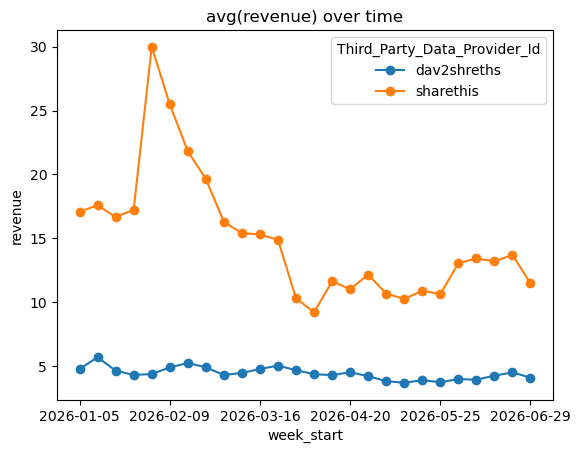

In [30]:
get_split_means(dat1, value = 'Data_Cost').plot(marker='o', title='avg(revenue) over time', ylabel='revenue')

<Axes: xlabel='week_start'>

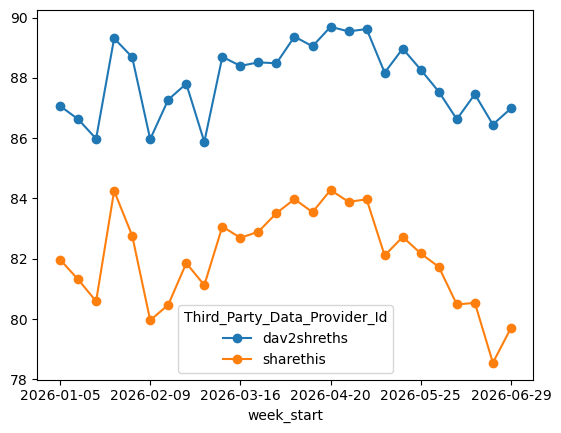

In [31]:
get_split_means(dat1, value = 'Avg_Relevance_Percentile').plot(marker='o')

# Model

In [32]:
dat2 = dat1
dat2['Received_ID_Count'] = dat2['Received_ID_Count'] + 1e-9
# also filter out rows not belonging to pricing experiment
dat2 = dat2[~dat2.group.isna()]

In [33]:
yr = dat2['Avg_Relevance_Percentile'] #['Avg_Relevance']
yd = dat2['Data_Cost'].astype(float) 

In [34]:
#seg_col = 'segment_last'
seg_col = 'segment_2'
#seg_col = 'Full_Path'

In [35]:
x_c_cols = list(dict.fromkeys([seg_col, 'week_start', 'Advertiser_Category', 'Third_Party_Data_Provider_Id', 'geo', 'segment_2']))
x_n_cols = ['Received_ID_Count', 'price', 'Avg_Relevance_Percentile'] #[ 'Active_ID_Count_Percentile', 'Paid_Pct_Percentile']
# 'Avg_Value_Percentile' has NAs

In [36]:
Xn = pd.DataFrame(dat2[x_n_cols], dtype=float)
Xn['log_Received_ID_Count'] = Xn['Received_ID_Count'].apply(lambda x: np.log(x))
x_n_cols += ['log_Received_ID_Count']

In [37]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xn = pd.DataFrame(sc.fit_transform(Xn), columns=Xn.columns, index=Xn.index)

In [38]:
Xc = pd.get_dummies(dat2[x_c_cols])

In [39]:
X = Xn.join(Xc)
X.head()

,Received_ID_Count,price,Avg_Relevance_Percentile,log_Received_ID_Count,segment_2_arts&entertainment,segment_2_automotive,segment_2_autos&vehicles,segment_2_beauty&fitness,segment_2_books&literature,segment_2_business&finance,...,week_start_2026-05-25,week_start_2026-06-01,week_start_2026-06-08,week_start_2026-06-15,week_start_2026-06-22,week_start_2026-06-29,Advertiser_Category_All,Third_Party_Data_Provider_Id_dav2shreths,Third_Party_Data_Provider_Id_sharethis,geo_Global
0,0.772360,0.232157,-0.308000,0.821578,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
1,0.704062,0.232157,-0.438385,0.819270,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
2,0.620192,0.232157,-0.633961,0.816287,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
3,0.644458,0.232157,0.425413,0.817168,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
4,0.714249,0.232157,-0.112423,0.819621,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True


# Revenue model

## Ridge

In [40]:
from sklearn.linear_model import Ridge

mod_d = Ridge(alpha=0.000001)
mod_d.fit(X, yd)
mod_d.score(X, yd)

0.02548722031658579

In [41]:
coef_d = pd.DataFrame(mod_d.coef_, index=X.columns, columns=['beta'])
coef_d['abs_beta'] = coef_d['beta'].abs()
coef_d_sorted = coef_d.sort_values('abs_beta', ascending=False)

In [42]:
coef_d_sorted[coef_d_sorted.beta > 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_2_validateddemographic,41.172934,41.172934
segment_2_people&society,38.474345,38.474345
segment_2_travel,33.199483,33.199483
segment_2_demographic,25.004137,25.004137
segment_2_law&government,14.236235,14.236235
segment_2_business&finance,11.927444,11.927444
segment_2_realestate,10.293719,10.293719
segment_2_health&wellness,5.276964,5.276964
segment_2_career&jobs,4.432102,4.432102
segment_2_hobbies&leisure,3.188273,3.188273


### some interesting betas

In [43]:
coef_d.filter(regex='Received', axis='index')

,beta,abs_beta
Received_ID_Count,7.317482,7.317482
log_Received_ID_Count,1.290843,1.290843


In [44]:
coef_d.filter(regex='Rel', axis='index')

,beta,abs_beta
Avg_Relevance_Percentile,0.540047,0.540047


In [45]:
coef_d.filter(regex='price', axis='index')

,beta,abs_beta
price,-0.35996,0.35996


In [46]:
coef_d.filter(regex='geo_', axis='index')

,beta,abs_beta
geo_Global,0.0,0.0


In [47]:
coef_d.filter(regex='Third_Party_Data_Provider_Id', axis='index')

,beta,abs_beta
Third_Party_Data_Provider_Id_dav2shreths,-3.593112,3.593112
Third_Party_Data_Provider_Id_sharethis,3.593129,3.593129


In [48]:
import matplotlib.pyplot as plt

def dfScatter(df, xcol='beta', ycol='Received_ID_Count', catcol='criterion', logx=False, logy=False):
    #fig, ax = plt.subplots()
    categories = np.unique(df[catcol])
    colors = np.linspace(0, 1, len(categories))
    colordict = dict(zip(categories, colors))  
    colors = df[catcol].apply(lambda x: colordict[x])
    return df.plot(kind='scatter', x=xcol, y=ycol, logy=logy, logx=logx, c=colors)

# RF to forecast demand curves

In [49]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [50]:
X_rf = X[X.columns[X.columns != 'log_Received_ID_Count']]

In [51]:
mod_d_rf = RFR(max_depth=5)
mod_d_rf.fit(X_rf, yd)
mod_d_rf.score(X_rf, yd)

0.24079773307517804

In [52]:
coef_d_rf = pd.DataFrame(mod_d_rf.feature_importances_, index=X_rf.columns, columns=['feature_importance'])
coef_d_rf_sorted = coef_d_rf.sort_values('feature_importance', ascending=False)
coef_d_rf_sorted.head(20)

,feature_importance
Received_ID_Count,0.411937
Avg_Relevance_Percentile,0.316320
week_start_2026-02-16,0.044589
week_start_2026-02-02,0.038101
segment_2_travel,0.032778
week_start_2026-02-09,0.027037
segment_2_people&society,0.021460
week_start_2026-02-23,0.017670
week_start_2026-01-05,0.015358
week_start_2026-01-12,0.010745


In [53]:
def sweep_forecast(X_rf, mod, sc, 
                   vary_feature, grid_unscaled, 
                   n_rows=1000,
                   geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']
                  ):
    """
    Sweep vary_feature across grid_unscaled, averaging revenue over n_rows real data rows.

    vary_feature : numeric feature name in sc.feature_names_in_
                   e.g. 'Received_ID_Count', 'price', 'Avg_Relevance_Percentile'
    grid_unscaled: array of raw (unscaled) values to sweep over
    n_rows       : number of real data rows to average over

    Returns DataFrame with columns: [vary_feature + '_unscaled', 'geo', 'revenue_forecast']
    """
    grid_unscaled = np.asarray(grid_unscaled)
    feat_idx = list(sc.feature_names_in_).index(vary_feature)
    grid_scaled = (grid_unscaled - sc.mean_[feat_idx]) / sc.scale_[feat_idx]

    X_rf2 = X_rf[X_rf.columns[X_rf.columns != vary_feature]]
    
    forecast_list = []
    for idx in range(min(n_rows, len(X_rf2))):
        samples_vary = pd.DataFrame(
            {vary_feature: grid_scaled},
            index=[X_rf2.index[idx]] * len(grid_scaled)
        )
        temp = samples_vary.join(X_rf2.iloc[[idx]])
        forecast_list.append(temp)

    fc = pd.concat(forecast_list)
    fc['revenue_forecast'] = mod.predict(fc[X_rf.columns])
    fc[vary_feature + '_unscaled'] = fc[vary_feature] * sc.scale_[feat_idx] + sc.mean_[feat_idx]
    fc['geo'] = fc.reindex(columns=geos).apply(
        lambda x: next((g.split('_')[1] for g in geos if x[g] == 1), 'Unknown'), axis=1
    )

    return fc.groupby(['geo', vary_feature + '_unscaled'])[['revenue_forecast']].mean().reset_index()


In [54]:
def extract_geo(x, geos):
    for geo in geos:
        if x[geo] == 1:
            return geo.split('_')[1]
    return "Unknown"

geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']


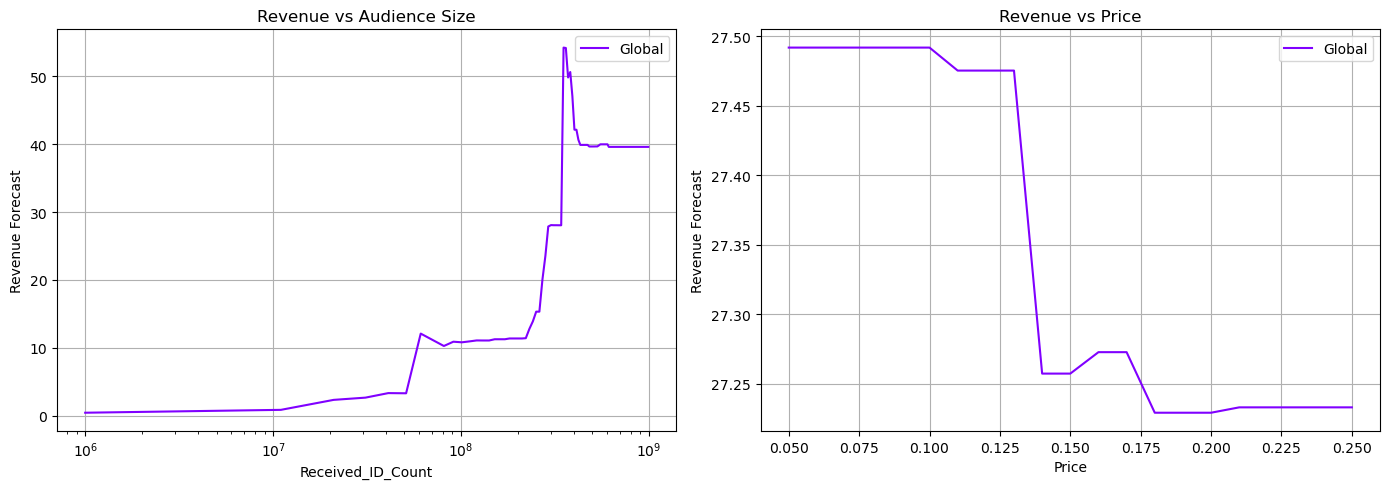

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Size sweep ---
size_grid = np.arange(1, 1000, 10) * 1_000_000
fc_size = sweep_forecast(X_rf, mod_d_rf, sc, 'Received_ID_Count', size_grid)
geos = fc_size['geo'].unique()
color = plt.cm.rainbow(np.linspace(0, 1, len(geos)))
for i, geo in enumerate(geos):
    sub = fc_size[fc_size['geo'] == geo]
    axes[0].plot(sub['Received_ID_Count_unscaled'], sub['revenue_forecast'], label=geo, color=color[i])
axes[0].set_xscale('log')
axes[0].set_xlabel('Received_ID_Count')
axes[0].set_ylabel('Revenue Forecast')
axes[0].set_title('Revenue vs Audience Size')
axes[0].legend()
axes[0].grid(True)

# --- Price sweep ---
price_grid = np.arange(0.05, 0.26, 0.01)
fc_price = sweep_forecast(X_rf, mod_d_rf, sc, 'price', price_grid)
geos_p = fc_price['geo'].unique()
color_p = plt.cm.rainbow(np.linspace(0, 1, len(geos_p)))
for i, geo in enumerate(geos_p):
    sub = fc_price[fc_price['geo'] == geo]
    axes[1].plot(sub['price_unscaled'], sub['revenue_forecast'], label=geo, color=color_p[i])
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Revenue Forecast')
axes[1].set_title('Revenue vs Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## DID

In [56]:
# Built from dat1 (Advertiser_Category=='All' only -- dat1_filled itself
# still has all 15 category rows per segment/week; see dat1's definition).
test = dat1[~dat1.group.isna()]
test = test[test.Week_Start_Date > test_df_start]
test = test[test.Third_Party_Data_Provider_Id == 'sharethis']
test_means = test.groupby(['group', 'Full_Path', 'delta', 'post'])[['Data_Cost']].mean()


In [57]:
test_means_joined = test_means.xs(0, level='post').join(
    test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post'
).reset_index()
test_means_joined['chg'] = test_means_joined['Data_Cost_post'] - test_means_joined['Data_Cost_pre']
test_means_joined['chg_ratio'] = test_means_joined['chg'] / test_means_joined['Data_Cost_pre']

In [58]:
test_means_joined.groupby('delta')[['chg']].describe()

chg                                                              \
       count      mean        std         min       25%    50%       75%   
delta                                                                      
-0.05  319.0  2.854441  49.137917 -626.606667  0.001667  0.285  2.909167   
 0.00  319.0  4.227863  72.736312  -67.933333 -0.140000  0.000  0.265833   
 0.05  319.0 -2.666855  21.649354 -227.753333 -0.550000  0.000  0.020000   

                    
               max  
delta               
-0.05   209.180000  
 0.00  1279.183333  
 0.05   112.201667

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>]],
      dtype=object)

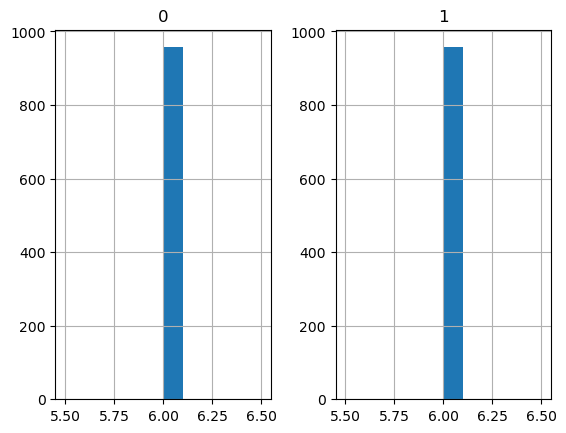

In [59]:
pd.DataFrame(test.groupby(['Full_Path','post']).size()).pivot_table(index='Full_Path', columns='post', values=0).hist()

In [60]:
import numpy as np
from scipy import stats
from scipy.stats import trim_mean as __trim_mean

# --- compute DiD ---
control_mean_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['chg']
    .mean()
    .rename('control_chg_mean')
)
did = (
    test_means_joined
    .join(control_mean_by_group, on='group')
    .dropna(subset=['control_chg_mean'])
    .copy()
)
did['did'] = did['chg'] - did['control_chg_mean']
control_level_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['Data_Cost_pre']
    .mean()
    .rename('control_level')
)
did = did.join(control_level_by_group, on='group')
did_col   = 'did'
did_label = 'DiD  (post-pre vs control)'

# --- shared functions ---
def ttest_trimmed(vals, trim=0.1):
    a = np.sort(vals)
    k = int(np.floor(trim * len(a)))
    return stats.ttest_1samp(a[k: len(a) - k], popmean=0)

def wilcoxon_safe(vals):
    try:
        _, p = stats.wilcoxon(vals)
        return p
    except ValueError:
        return 1.0  # all values zero — no evidence against null

def p_label(p):
    if p < 0.001: return 'p<0.001'
    if p < 0.05:  return f'p={p:.3f}'
    return f'p={p:.3f} (n.s.)'

def desc_stats(did, col):
    rows = []
    for d in sorted(did['delta'].unique()):
        vals = did[did['delta'] == d][col].dropna().values
        _, p_t     = stats.ttest_1samp(vals, popmean=0)
        _, p_trim  = ttest_trimmed(vals)
        p_wilcox   = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        rows.append({
            'delta': d, 'n': len(vals),
            'mean':  round(float(vals.mean()), 3),
            'std':   round(float(vals.std()),  3),
            'cdf0':  round(float((vals <= 0).mean()), 3),
            'p5':    q(0.05), 'q25': q(0.25), 'median': q(0.50),
            'q75':   q(0.75), 'p95': q(0.95),
            'p_t':      round(float(p_t),      4),
            'p_trim':   round(float(p_trim),   4),   # drops top/bottom 10%
            'p_wilcox': round(float(p_wilcox), 4),   # rank-based
        })
    return pd.DataFrame(rows)

# --- shared building blocks for every 'relative DiD' number in this notebook ---
# Used identically by desc_stats_agg_rel below AND by the ATE cell, so that any
# two 'relative DiD' figures are guaranteed to differ only in the arguments
# passed (grouping / weights / scale / baseline), never in the formula.
def apply_estimator(vals, estimator='median', trim=0.1):
    vals = np.asarray(vals)
    if estimator == 'mean':   return float(np.mean(vals))
    if estimator == 'trim':   return float(__trim_mean(vals, trim))
    if estimator == 'median': return float(np.median(vals))
    if estimator == 'sum':    return float(np.sum(vals))
    raise ValueError(estimator)

def relative_did(numerator_value, scale=1.0, baseline=None, denominator_value=None):
    """
    total = numerator_value * scale
    rel   = total / baseline               if baseline is given
                                            (an independently measured total, e.g.
                                             total_panel_weekly_rev -- used by the ATE cell)
          = total / (denominator_value * scale)  otherwise
                                            (a same-sample proxy, e.g. control_level --
                                             used by desc_stats_agg_rel's ratio of
                                             aggregates below)
    Exactly one of `baseline` / `denominator_value` should be given.
    """
    total = numerator_value * scale
    den = baseline if baseline is not None else denominator_value * scale
    return total, den, (total / den if den else float('nan'))

def desc_stats_agg_rel(did, num_col='did', den_col='control_level', trim=0.1, cross_pairs=(('median', 'mean'),)):
    """Relative DiD via ratio-of-aggregates: aggregate num_col and den_col
    separately per delta (no grouping, scale=1, no external baseline -- the
    within-experiment-sample case), THEN take the ratio. This is the only
    relative-DiD view kept in this notebook -- a per-segment did/control_level
    ratio isn't computed as a standalone column since dividing by a possibly
    near-zero control_level per segment is noisy (and zero-filling missing
    weeks, see dat1_filled above, makes near-zero control_level more common,
    not less). Aggregating first avoids that: a few tiny-control_level segments
    can't dominate a sum the way they would dominate a mean/median of per-row ratios.

    Reports the matched-estimator pairs (mean/mean, trim/trim, median/median,
    sum/sum) plus any `cross_pairs` (num_estimator, den_estimator) -- e.g. the
    default median(did)/mean(lvl) checks whether using a more stable mean for
    the denominator changes the picture versus matching median to median.
    """
    matched_pairs = [(est, est) for est in ['mean', 'trim', 'median', 'sum']]
    pairs = matched_pairs + [p for p in cross_pairs if p not in matched_pairs]
    rows = []
    for d in sorted(did['delta'].unique()):
        sub = did[did['delta'] == d].dropna(subset=[num_col, den_col])
        num_vals, den_vals = sub[num_col].values, sub[den_col].values
        row = {'delta': d, 'n': len(sub)}
        for num_est, den_est in pairs:
            num = apply_estimator(num_vals, num_est, trim)
            den = apply_estimator(den_vals, den_est, trim)
            _, _, rel = relative_did(num, denominator_value=den)
            row[f'{num_est}(did)/{den_est}(lvl)'] = round(rel, 4)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_did_bars(ax, did, col, metric='mean', trim=0.0):
    """One bar chart panel. metric='mean' uses trimmed-t; 'median' uses Wilcoxon."""
    deltas = sorted(did['delta'].unique())
    centers, spreads, pvals = [], [], []
    for d in deltas:
        vals = did[did['delta'] == d][col].dropna().values
        if metric == 'mean':
            _, p = ttest_trimmed(vals)
            centers.append(float(__trim_mean(vals, trim)) if trim > 0 else float(vals.mean()))
            if trim > 0:
                _k = int(np.floor(trim * len(vals)))
                _trimmed = np.sort(vals)[_k: len(vals) - _k]
                spreads.append(1.96 * float(stats.sem(_trimmed)) if len(_trimmed) > 1 else 0.0)
            else:
                spreads.append(1.96 * float(stats.sem(vals)))
        else:
            p = wilcoxon_safe(vals)
            centers.append(float(np.median(vals)))
            spreads.append((float(np.quantile(vals, 0.75)) - float(np.quantile(vals, 0.25))) / 2)
        pvals.append(float(p))
    ax.bar([str(d) for d in deltas], centers, yerr=spreads, capsize=5,
           color=['steelblue', 'brown', 'tomato'])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ylo, yhi = ax.get_ylim()
    new_yhi = yhi + (yhi - ylo) * 0.08 * len(deltas)
    ax.set_ylim(ylo, new_yhi)
    for i, (p, center, spread) in enumerate(zip(pvals, centers, spreads)):
        ax.text(i, center + spread + (new_yhi - ylo) * 0.02,
                p_label(p), ha='center', va='bottom', fontsize=8)
        # DiD estimate: annotate at bar midpoint (white inside tall bars,
        # dark just outside near-zero bars so the value is always readable)
        rng = new_yhi - ylo
        if rng > 0 and abs(center) > rng * 0.04:
            ax.text(i, center / 2, f'{center:.3g}',
                    ha='center', va='center', fontsize=7.5,
                    fontweight='bold', color='white')
        else:
            offset = (rng * 0.02) * (1 if center >= 0 else -1)
            ax.text(i, center + offset, f'{center:.3g}',
                    ha='center', va='bottom' if center >= 0 else 'top',
                    fontsize=7.5, color='#333')
    ax.grid(axis='y', alpha=0.4)

 delta   n   mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 319 -1.373 111.856 0.323  -7.631 -0.011   0.223 3.832 31.470 0.8268  0.0000    0.0000
  0.00 319  0.000   0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 319 -6.895  75.486 0.608 -22.820 -1.183   0.000 0.479 12.772 0.1043  0.0001    0.0529


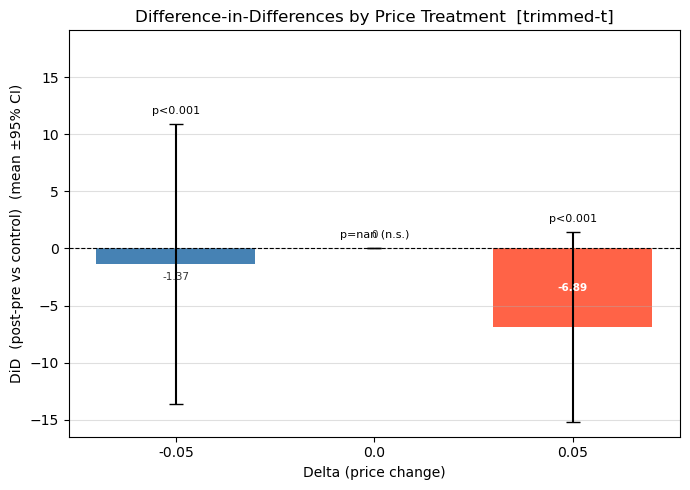

In [61]:
# --- overview: stats table + single bar chart ---
print(desc_stats(did, did_col).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
plot_did_bars(ax, did, did_col, metric='mean')
ax.set_xlabel('Delta (price change)')
ax.set_ylabel(f'{did_label}  (mean ±95% CI)')
ax.set_title('Difference-in-Differences by Price Treatment  [trimmed-t]')
plt.tight_layout()
plt.show()

=== DiD  (post-pre vs control) ===
 delta   n   mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 319 -1.373 111.856 0.323  -7.631 -0.011   0.223 3.832 31.470 0.8268  0.0000    0.0000
  0.00 319  0.000   0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 319 -6.895  75.486 0.608 -22.820 -1.183   0.000 0.479 12.772 0.1043  0.0001    0.0529

=== raw (chg) ===
 delta   n   mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 319  2.854 49.061 0.238  -1.726  0.002   0.285 2.909 27.548 0.3003  0.0000    0.0000
  0.00 319  4.228 72.622 0.611  -8.295 -0.140   0.000 0.266  7.898 0.3000  0.8796    0.7089
  0.05 319 -2.667 21.615 0.696 -16.447 -0.550   0.000 0.020  6.725 0.0285  0.0000    0.0010

=== relative DiD -- ratio of aggregates (only relative-DiD view kept) ===
(agg(did $) / agg(control_level $), aggregated before dividing -- avoids the
 noise a per-segment did/control_level ratio gets when

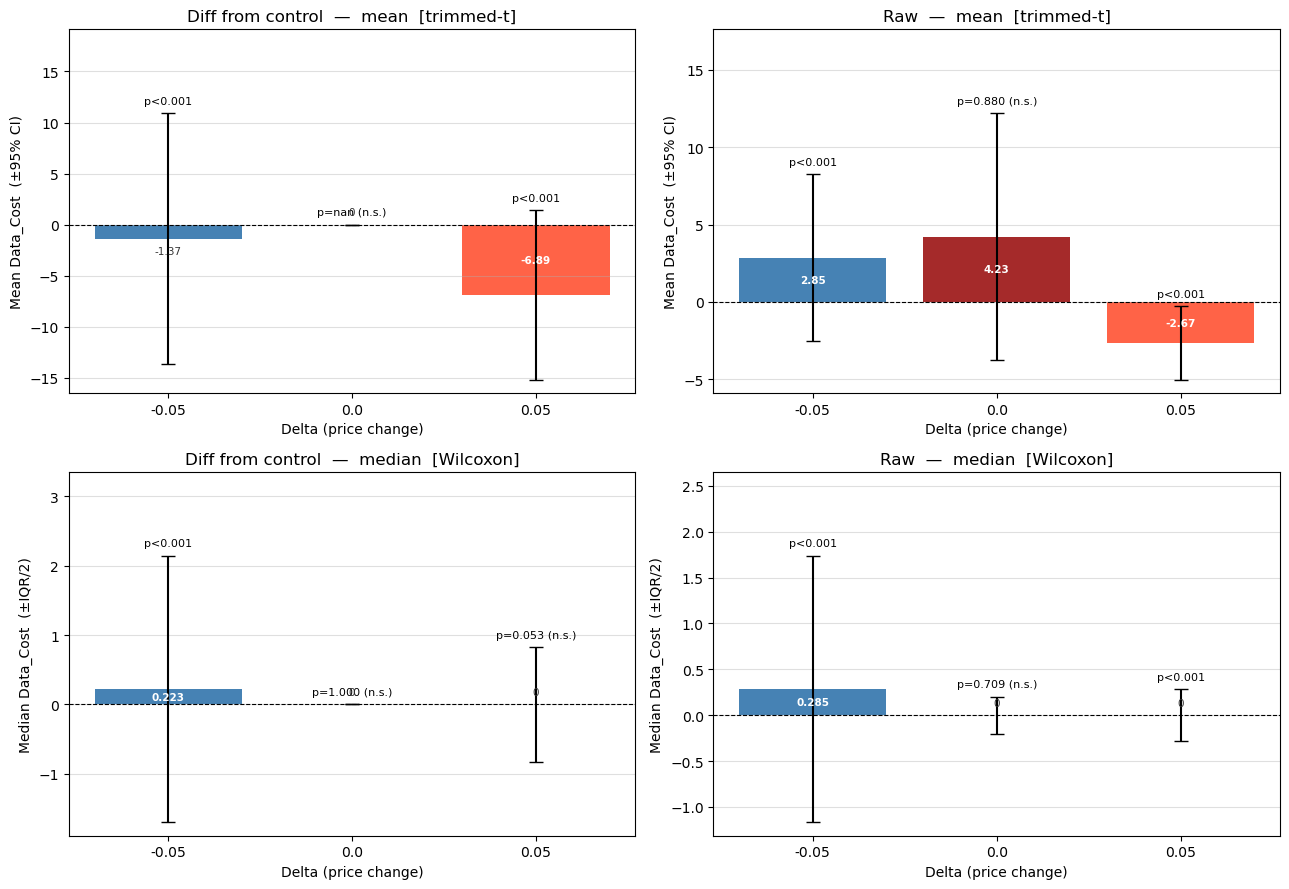

In [62]:
print(f'=== {did_label} ===')
print(desc_stats(did, did_col).to_string(index=False))
print()
print('=== raw (chg) ===')
print(desc_stats(did, 'chg').to_string(index=False))
print()
print('=== relative DiD -- ratio of aggregates (only relative-DiD view kept) ===')
print('(agg(did $) / agg(control_level $), aggregated before dividing -- avoids the')
print(' noise a per-segment did/control_level ratio gets whenever control_level is')
print(' near zero, which is common after zero-filling missing weeks)')
print(desc_stats_agg_rel(did).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, metric in enumerate(['mean', 'median']):
    for col, value in enumerate(['diff from control', 'raw']):
        ax = axes[row][col]
        dcol = did_col if value == 'diff from control' else 'chg'
        spread_label = '±95% CI' if metric == 'mean' else '±IQR/2'
        p_method = 'trimmed-t' if metric == 'mean' else 'Wilcoxon'
        plot_did_bars(ax, did, dcol, metric=metric)
        ax.set_xlabel('Delta (price change)')
        ax.set_ylabel(f'{metric.capitalize()} Data_Cost  ({spread_label})')
        ax.set_title(f'{value.capitalize()}  —  {metric}  [{p_method}]')
plt.tight_layout()
plt.show()


# analysis by bucket

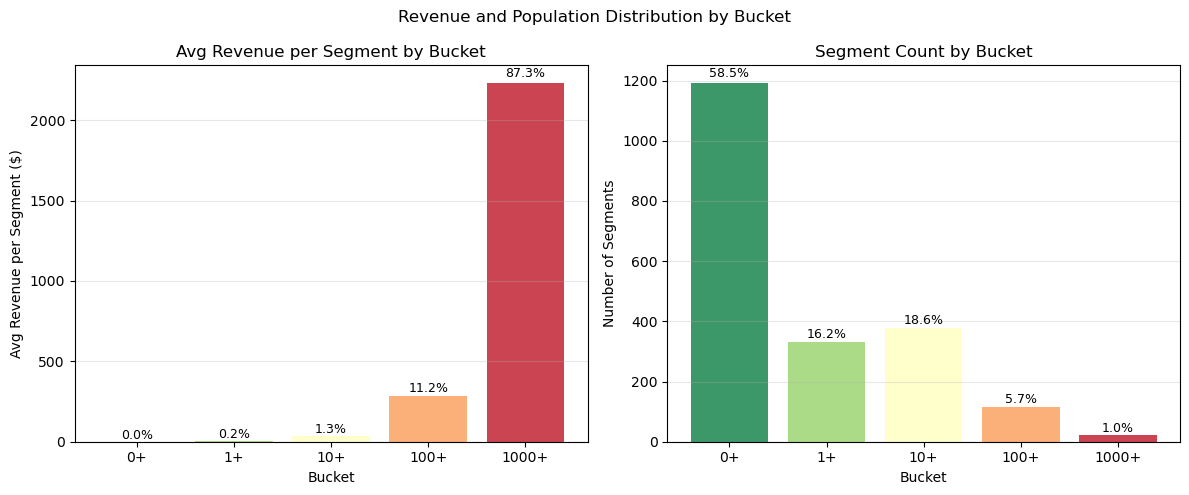

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# step 1: avg revenue per segment (Full_Path)
seg_rev = (
    pricing.groupby("Full_Path")
    .agg(revenue=("revenue", "mean"), bucket=("bucket", "first"))
)

# step 2: avg of those per-segment revenues by bucket
rev_by_bucket = seg_rev.groupby("bucket")["revenue"].mean().reindex(BUCKET_ORDER)
axes[0].bar(rev_by_bucket.index, rev_by_bucket.values, color=[BUCKET_COLORS[b] for b in BUCKET_ORDER], alpha=0.8)
axes[0].set_title("Avg Revenue per Segment by Bucket")
axes[0].set_xlabel("Bucket")
axes[0].set_ylabel("Avg Revenue per Segment ($)")
for i, v in enumerate(rev_by_bucket.values):
    pct = v / rev_by_bucket.sum() * 100
    axes[0].text(i, v * 1.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# segment count by bucket
pop_by_bucket = seg_rev.groupby("bucket").size().reindex(BUCKET_ORDER)
axes[1].bar(pop_by_bucket.index, pop_by_bucket.values, color=[BUCKET_COLORS[b] for b in BUCKET_ORDER], alpha=0.8)
axes[1].set_title("Segment Count by Bucket")
axes[1].set_xlabel("Bucket")
axes[1].set_ylabel("Number of Segments")
for i, v in enumerate(pop_by_bucket.values):
    pct = v / pop_by_bucket.sum() * 100
    axes[1].text(i, v * 1.01, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Revenue and Population Distribution by Bucket")
plt.tight_layout()
plt.show()

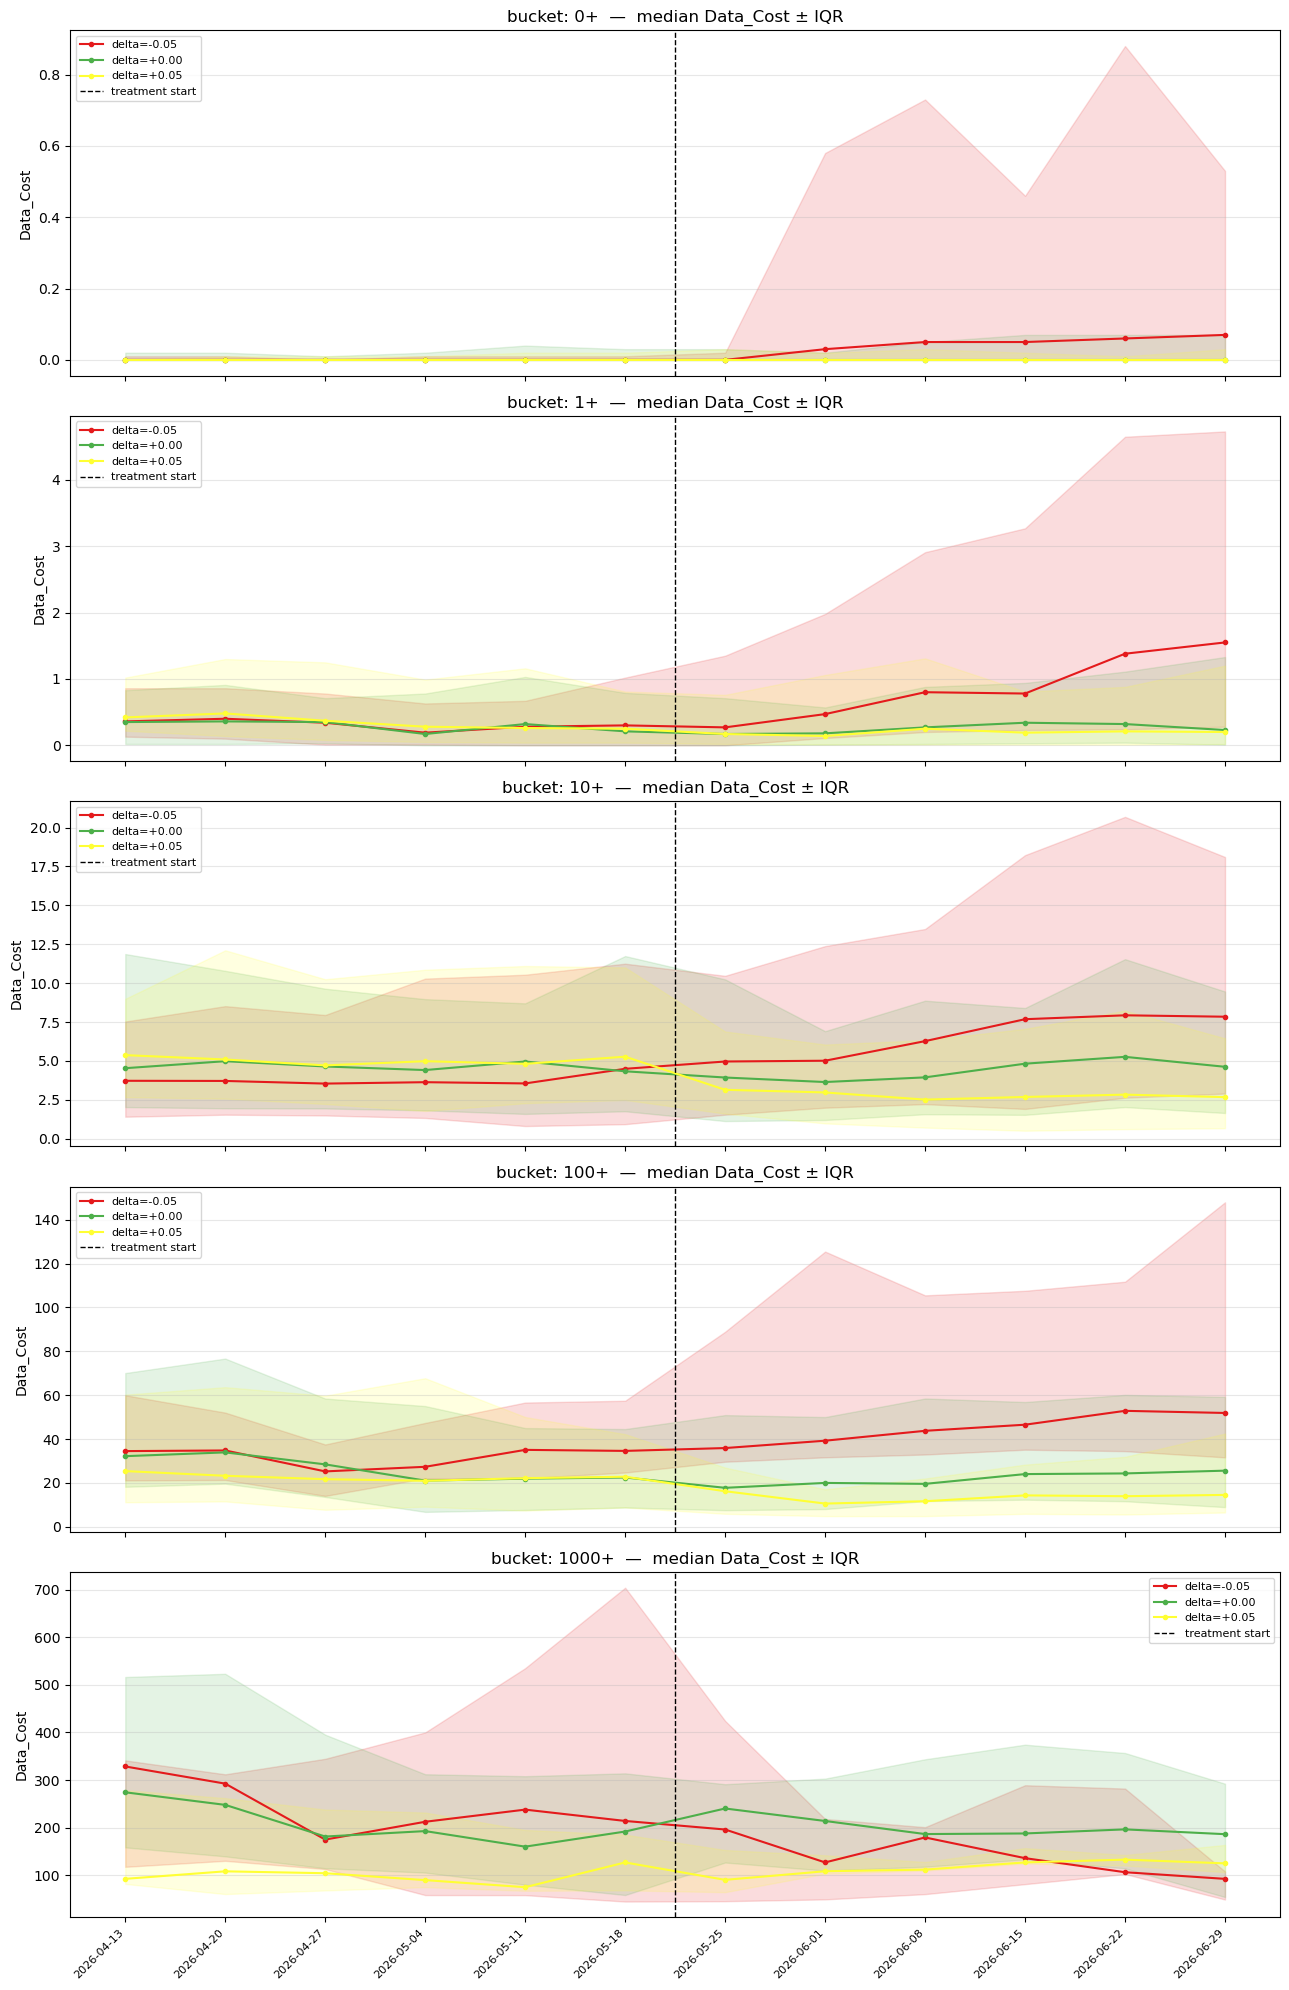

In [64]:
import matplotlib.pyplot as plt

buckets = BUCKET_ORDER
delta_vals = sorted(test['delta'].unique())
dates_all = sorted(test['Week_Start_Date'].unique())
xs = list(range(len(dates_all)))
colors = plt.cm.Set1([0, 0.33, 0.66])  # one color per delta

fig, axes = plt.subplots(len(buckets), 1, figsize=(13, 4 * len(buckets)), sharex=True)

for ax, bucket in zip(axes, buckets):
    sub = test[test['bucket'] == bucket]

    for color, delta in zip(colors, delta_vals):
        grp = sub[sub['delta'] == delta].groupby('Week_Start_Date')['Data_Cost']
        medians = [grp.get_group(d).median() if d in grp.groups else np.nan for d in dates_all]
        q25     = [grp.get_group(d).quantile(0.25) if d in grp.groups else np.nan for d in dates_all]
        q75     = [grp.get_group(d).quantile(0.75) if d in grp.groups else np.nan for d in dates_all]

        ax.plot(xs, medians, marker='o', markersize=3, linewidth=1.5,
                label=f'delta={delta:+.2f}', color=color)
        ax.fill_between(xs, q25, q75, alpha=0.15, color=color)

    treat_idx = next((i for i, d in enumerate(dates_all) if str(d) > last_pre_week), None)
    if treat_idx is not None:
        ax.axvline(treat_idx - 0.5, color='black', linestyle='--', linewidth=1, label='treatment start')

    ax.set_title(f'bucket: {bucket}  —  median Data_Cost ± IQR')
    ax.set_ylabel('Data_Cost')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xticks(xs)
axes[-1].set_xticklabels([str(d)[:10] for d in dates_all], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


In [65]:
import matplotlib.ticker as mtick
import numpy as np

# join bucket from pricing into did
bucket_lookup = pricing[['Full_Path', 'bucket']].drop_duplicates().set_index('Full_Path')
did_b = did.join(bucket_lookup, on='Full_Path')
buckets = BUCKET_ORDER

# extract segment_2 from Full_Path
did_b['segment_2'] = did_b['Full_Path'].apply(
    lambda x: x.lower().replace(" ", "").replace("otp>", "").split(">")[1]
    if len(x.replace(" ", "").split(">")) > 1 else "N/A"
)

# ── stats by bucket ──────────────────────────────────────────────────────────
for bucket in buckets:
    sub = did_b[did_b['bucket'] == bucket]
    print(f"=== bucket: {bucket}  (n={len(sub)}) ===")
    print(desc_stats(sub, did_col).to_string(index=False))
    print()


=== bucket: 0+  (n=471) ===
 delta   n   mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 157  0.466 8.115 0.318 -0.866  0.000   0.047 0.758 6.909 0.4738  0.0000    0.0000
  0.00 157  0.000 0.000 1.000  0.000  0.000   0.000 0.000 0.000    NaN     NaN    1.0000
  0.05 157 -0.437 7.706 0.637 -2.403 -0.032   0.000 0.040 1.797 0.4795  0.5585    0.8401

=== bucket: 1+  (n=159) ===
 delta  n   mean   std  cdf0     p5    q25  median  q75   p95    p_t  p_trim  p_wilcox
 -0.05 53  2.854 9.793 0.264 -0.924 -0.022   0.618 3.25 7.755 0.0405  0.0000    0.0001
  0.00 53  0.000 0.000 1.000  0.000  0.000   0.000 0.00 0.000    NaN     NaN    1.0000
  0.05 53 -0.048 2.113 0.566 -2.800 -0.773  -0.053 0.57 3.140 0.8696  0.6027    0.5384

=== bucket: 10+  (n=231) ===
 delta  n  mean    std  cdf0      p5    q25  median    q75    p95    p_t  p_trim  p_wilcox
 -0.05 77 7.201 17.198 0.338  -7.942 -1.773   3.463 13.242 34.519 0.0005  0.0000    0.0002
  0.00 77 0.000  0.000 1.00

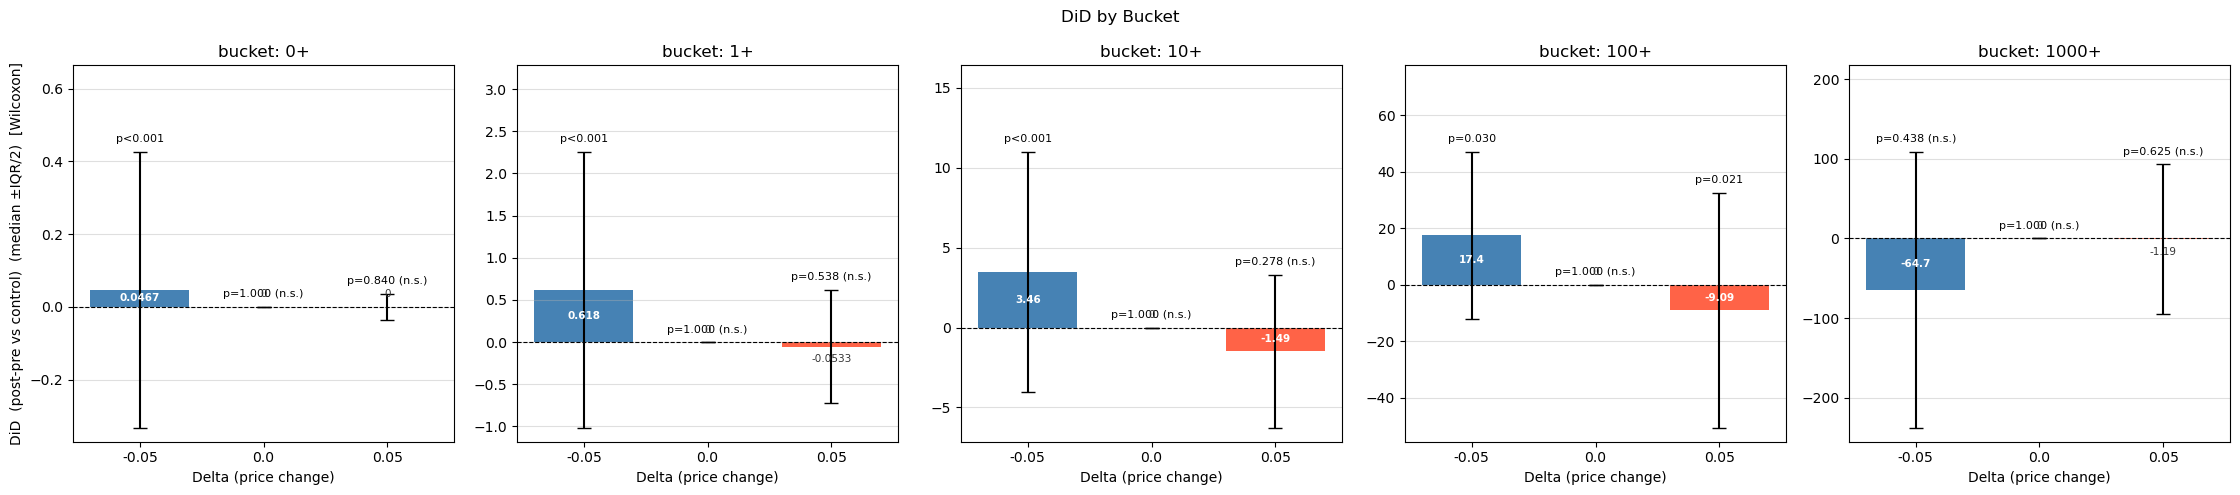

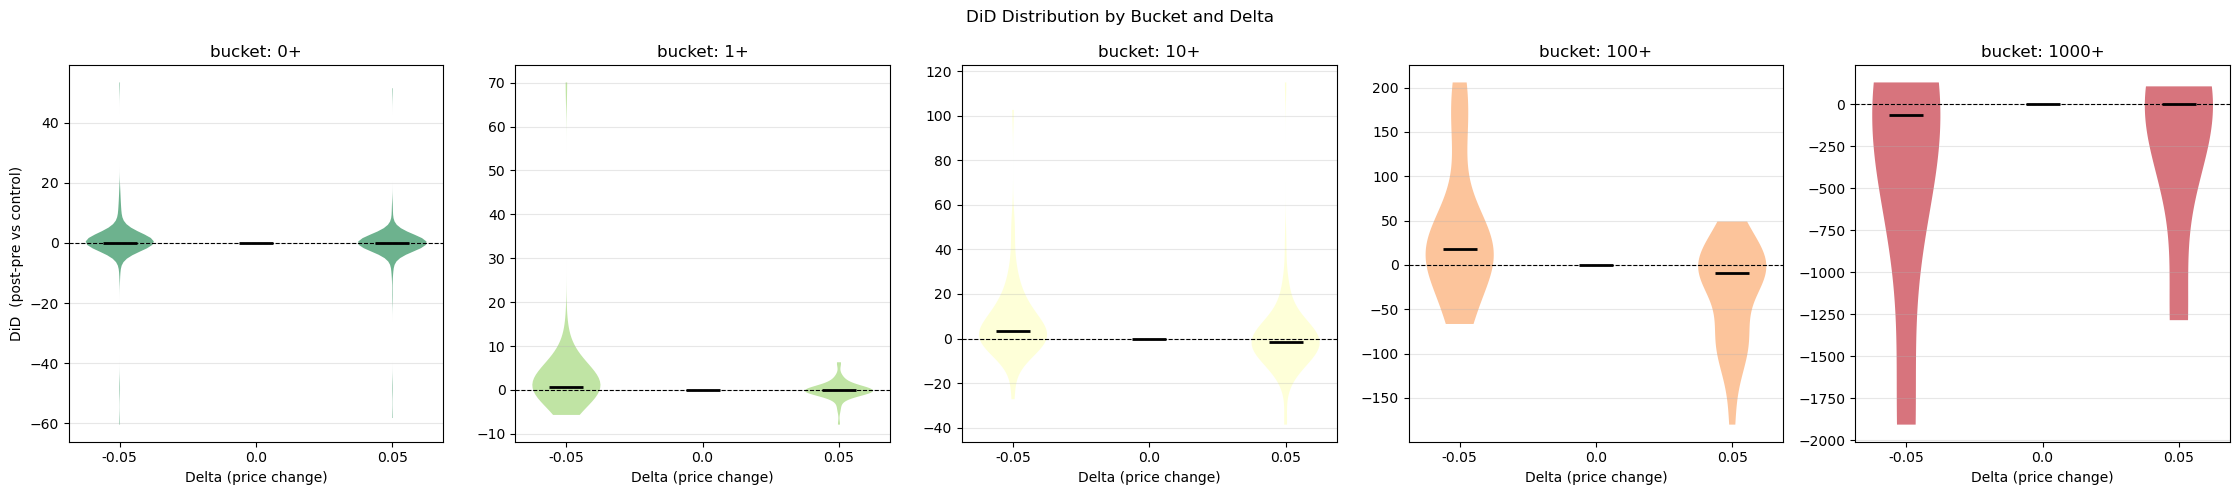

In [66]:
# ── 1. per-bucket bar charts (median DiD by delta) ──────────────────────────
fig, axes = plt.subplots(1, len(buckets), figsize=(4.5 * len(buckets), 5), sharey=False)
# NOTE sharey=False: bucket scales can now differ by orders of magnitude (e.g. a
# '1000+' tier's DiD vs a '0+' tier's near-zero DiD), unlike the old fixed
# 3-tier scheme where all buckets were roughly comparable. Sharing a y-axis
# across such different scales also triggered a matplotlib tight-bbox
# rendering bug (absurd canvas size) when one bucket's range swamped the rest.
for ax, bucket in zip(axes, buckets):
    sub = did_b[did_b['bucket'] == bucket]
    plot_did_bars(ax, sub, did_col, metric='median')
    ax.set_title(f'bucket: {bucket}')
    ax.set_xlabel('Delta (price change)')
axes[0].set_ylabel(f'{did_label}  (median ±IQR/2)  [Wilcoxon]')
fig.suptitle('DiD by Bucket')
plt.tight_layout()
plt.show()

# ── 2. violin distributions by (bucket, delta) ──────────────────────────────
fig, axes = plt.subplots(1, len(buckets), figsize=(4.5 * len(buckets), 5), sharey=False)  # see note above
deltas = sorted(did_b['delta'].unique())

for ax, bucket in zip(axes, buckets):
    sub = did_b[did_b['bucket'] == bucket]
    data = [sub[sub['delta'] == d][did_col].dropna().values for d in deltas]
    parts = ax.violinplot(data, positions=list(range(len(deltas))),
                          showmedians=True, showextrema=False)
    for body in parts['bodies']:
        body.set_facecolor(BUCKET_COLORS[bucket]); body.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(deltas)))
    ax.set_xticklabels([str(d) for d in deltas])
    ax.set_xlabel('Delta (price change)')
    ax.set_title(f'bucket: {bucket}')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel(did_label)
fig.suptitle('DiD Distribution by Bucket and Delta')
plt.tight_layout()
plt.show()

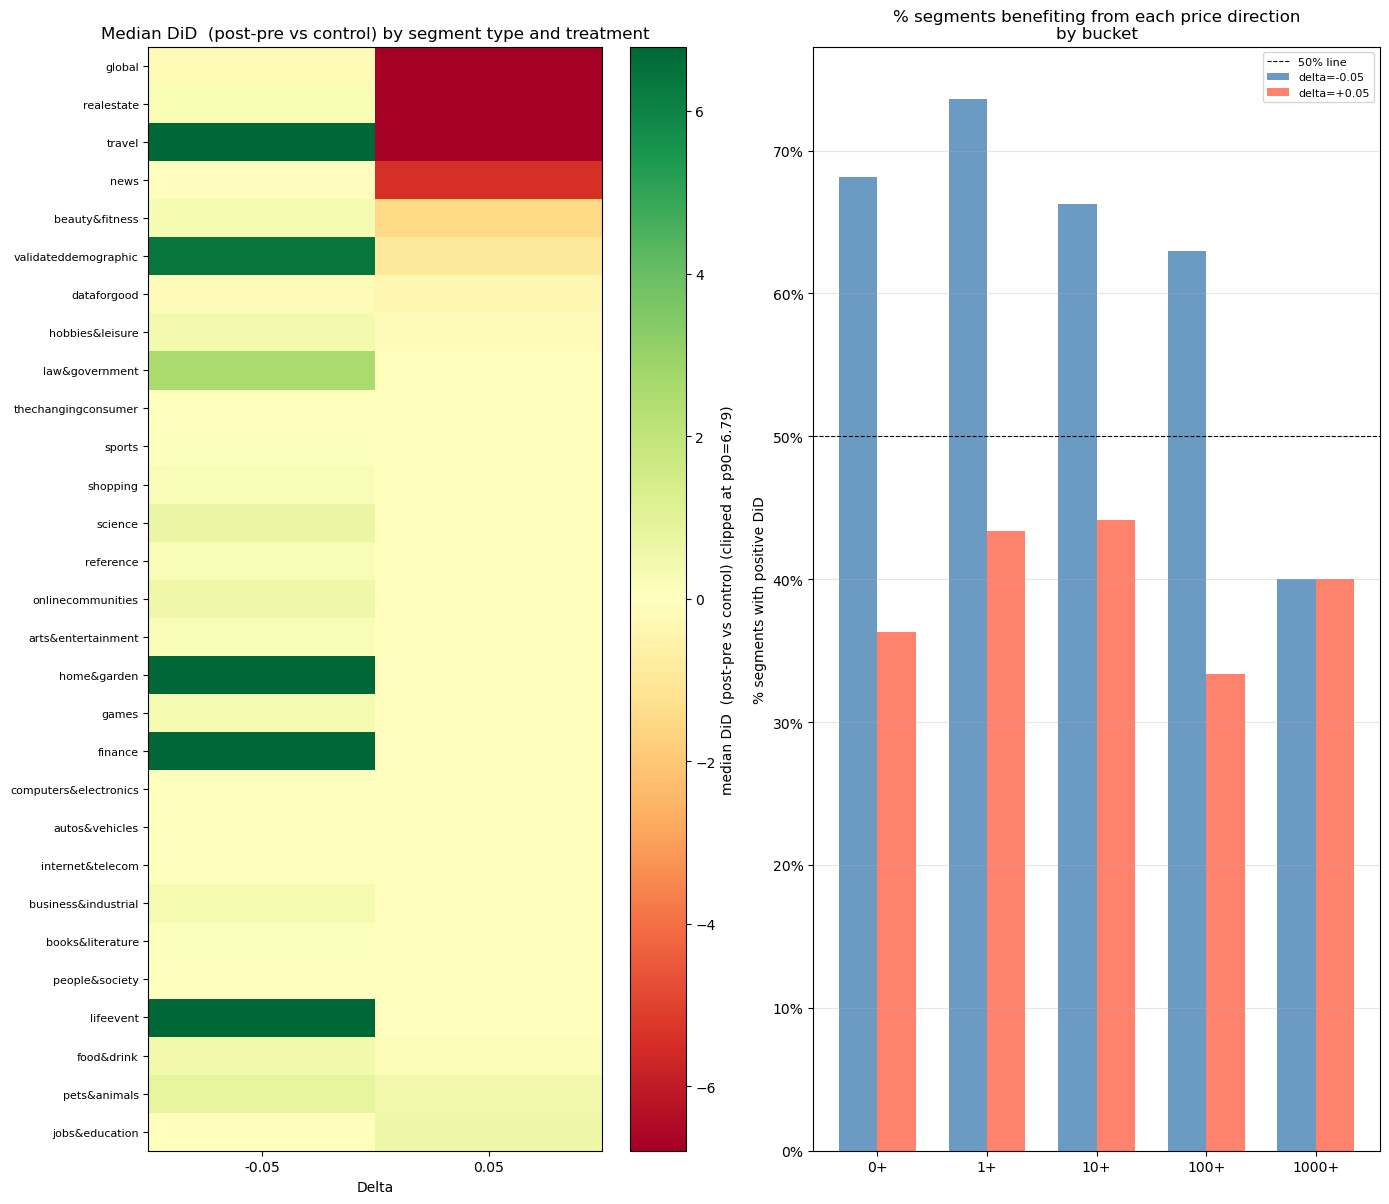

In [67]:
# segment_2 × delta median DiD (used in plots below)
# seg_col = segment_2
hm = (
    did_b[did_b['delta'] != 0]
    .groupby([seg_col, 'delta'])[did_col]
    .median()
    .unstack('delta')
    .dropna()
    .sort_values(did_b['delta'].max())
)

# ── 3. segment-type preference ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(hm) * 0.35 + 2)))

# left: heatmap — median DiD per (segment_2, delta)
vmax = np.percentile(abs(hm.values), 90)
im = axes[0].imshow(hm.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=axes[0], label=f'median {did_label} (clipped at p90={vmax:.2f})')
axes[0].set_xticks(range(len(hm.columns)))
axes[0].set_xticklabels([str(c) for c in hm.columns])
axes[0].set_yticks(range(len(hm.index)))
axes[0].set_yticklabels(hm.index, fontsize=8)
axes[0].set_xlabel('Delta')
axes[0].set_title(f'Median {did_label} by segment type and treatment')

# right: % of segments with positive DiD per (bucket, delta)
ax = axes[1]
x = np.arange(len(buckets))
width = 0.35
for di, (d, color) in enumerate(zip([-0.05, 0.05], ['steelblue', 'tomato'])):
    pcts = []
    for b in buckets:
        vals = did_b[(did_b['bucket'] == b) & (did_b['delta'] == d)][did_col].dropna()
        pcts.append((vals > 0).mean() * 100 if len(vals) > 0 else 0)
    ax.bar(x + di * width, pcts, width, label=f'delta={d:+.2f}', color=color, alpha=0.8)
ax.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% line')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(buckets)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('% segments with positive DiD')
ax.set_title('% segments benefiting from each price direction\nby bucket')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Segment-level outliers by bucket — which segments favor the opposite price?

The bucket-level plots above show the *typical* direction (decrease vs increase) each bucket favors, but that's an average — individual segments can disagree. This section finds those disagreements, with the **high** bucket as the primary focus (largest-revenue segments, most consequential to get right).

This uses **did (abs $)** — per-segment dollar DiD — to flag "against-trend" segments: within a bucket+delta group, a segment is against-trend if its own `did` has the opposite sign from that group's median `did`. E.g. if a bucket's decrease group typically shows positive `did` (decrease is favorable), a segment with negative `did` there is a candidate for a price *increase* instead — and symmetrically, a segment with positive `did` in a typically-unfavorable increase group is a candidate for *further* increase.

The bucket-level **ratio-of-aggregates** (`desc_stats_agg_rel`, next cell) remains the relative-DiD view for context. A per-segment did/control_level ratio isn't shown here — it's too noisy whenever control_level is near zero (see the revenue-DiD section above for why that column was dropped).

In [68]:
# ─── Bucket x delta aggregate direction — method 2 (ratio of aggregates) ──────
# Dollar-weighted relative DiD per bucket, for comparison against the per-segment
# median-based "typical direction" used to flag outliers below. A gap between
# sum(did)/sum(lvl) here and the per-segment median sign means a few large
# control_level segments are pulling the aggregate away from what most segments
# individually show.
bucket_direction = {}
for bucket in buckets:
    sub = did_b[(did_b['bucket'] == bucket) & (did_b['delta'] != 0)]
    agg = desc_stats_agg_rel(sub, num_col='did', den_col='control_level')
    print(f"--- bucket: {bucket} (n={len(sub)}) ---")
    print(agg.to_string(index=False))
    print()
    bucket_direction[bucket] = agg.set_index('delta')['sum(did)/sum(lvl)']

--- bucket: 0+ (n=314) ---
 delta   n  mean(did)/mean(lvl)  trim(did)/trim(lvl)  median(did)/median(lvl)  sum(did)/sum(lvl)  median(did)/mean(lvl)
 -0.05 157               0.3613              12.4952                      NaN             0.3613                 0.0361
  0.05 157              -0.3387               0.4123                      NaN            -0.3387                 0.0000

--- bucket: 1+ (n=106) ---
 delta  n  mean(did)/mean(lvl)  trim(did)/trim(lvl)  median(did)/median(lvl)  sum(did)/sum(lvl)  median(did)/mean(lvl)
 -0.05 53               1.6947               2.4676                   1.4000             1.6947                 0.3672
  0.05 53              -0.0287              -0.1203                  -0.1208            -0.0287                -0.0317

--- bucket: 10+ (n=154) ---
 delta  n  mean(did)/mean(lvl)  trim(did)/trim(lvl)  median(did)/median(lvl)  sum(did)/sum(lvl)  median(did)/mean(lvl)
 -0.05 77               0.7426               0.8000                   0.6278    

In [69]:
# ─── Per-segment outliers vs bucket-typical direction ─────────────────────────
# "against_trend" = this segment's did sign disagrees with the median did for
# its own bucket+delta group (the group's typical/majority direction).
pd.set_option('display.width', 140)
pd.set_option('display.max_colwidth', 60)

outlier_tables = {}
for bucket in buckets:
    sub = did_b[(did_b['bucket'] == bucket) & (did_b['delta'] != 0)].copy()
    # Reference direction = median of NONZERO did only. Zero-filling missing weeks
    # (see dat1_filled) makes did==0 common (segments with zero revenue pre AND
    # post -- no measurable effect, not "the wrong effect"), which can drag the
    # raw median to ~0 or exactly 0. Comparing sign(did) to sign(a near-zero or
    # exactly-zero median) either flags every flat segment as "against trend"
    # alongside genuinely opposite-signed ones, or (if median==0 exactly) flags
    # every nonzero segment regardless of direction. Excluding zeros from both
    # the reference and the flag itself keeps "against trend" meaning what it
    # should: a real, oppositely-signed effect, not merely "not flat."
    nonzero_median_did = sub[sub['did'] != 0].groupby('delta')['did'].median()
    sub['bucket_median_did'] = sub['delta'].map(nonzero_median_did)
    sub['against_trend'] = (sub['did'] != 0) & (np.sign(sub['did']) != np.sign(sub['bucket_median_did']))
    outlier_tables[bucket] = sub.sort_values(['delta', 'did'])

cols = ['Full_Path', 'delta', 'did', 'control_level', 'against_trend']
N_HIGH, N_OTHER = 15, 8   # rows shown per delta group; full tables in outlier_tables[bucket]

for bucket in buckets:
    sub = outlier_tables[bucket]
    n_against = int(sub['against_trend'].sum())
    n_flat = int((sub['did'] == 0).sum())
    pct_positive = sub.groupby('delta')['did'].apply(lambda v: (v > 0).mean() * 100)
    print(f"--- bucket: {bucket}  ({n_against}/{len(sub)} segments against their delta-group's median direction, "
          f"{n_flat} flat/no-effect) ---")
    print("    % positive did by delta: " + ", ".join(f"{d:+.2f}: {p:.0f}%" for d, p in pct_positive.items()))
    n_show = N_HIGH if bucket == BUCKET_ORDER[-1] else N_OTHER  # top bucket gets full detail
    for d in sorted(sub['delta'].unique()):
        against = sub[(sub['delta'] == d) & sub['against_trend']]
        against = against.reindex(against['did'].abs().sort_values(ascending=False).index)
        direction = 'decrease' if d < 0 else 'increase'
        med = sub[sub['delta'] == d]['did'].median()
        typical = 'favorable' if med > 0 else 'unfavorable'
        print(f"\n  delta={d:+.2f} ({direction}, typically {typical}, median did={med:,.1f})"
              f" -- top {min(n_show, len(against))} outliers of {len(against)} against-trend:")
        print(against[cols].head(n_show).to_string(index=False))
    print()

--- bucket: 0+  (80/314 segments against their delta-group's median direction, 70 flat/no-effect) ---
    % positive did by delta: -0.05: 68%, +0.05: 36%

  delta=-0.05 (decrease, typically favorable, median did=0.0) -- top 8 outliers of 31 against-trend:
                                                              Full_Path  delta        did  control_level  against_trend
              Global > Data for Good > Current Affairs - Social Justice  -0.05 -60.531667      28.556667           True
                                              Global > people & society  -0.05 -48.465000       8.168333           True
               Global > computers & electronics > programming > c & c++  -0.05 -10.000000       0.000000           True
                           Global > computers & electronics > cad & cam  -0.05  -7.618333       0.016667           True
                             Global > news > journalism & news industry  -0.05  -5.475000       0.176667           True
            Global > law

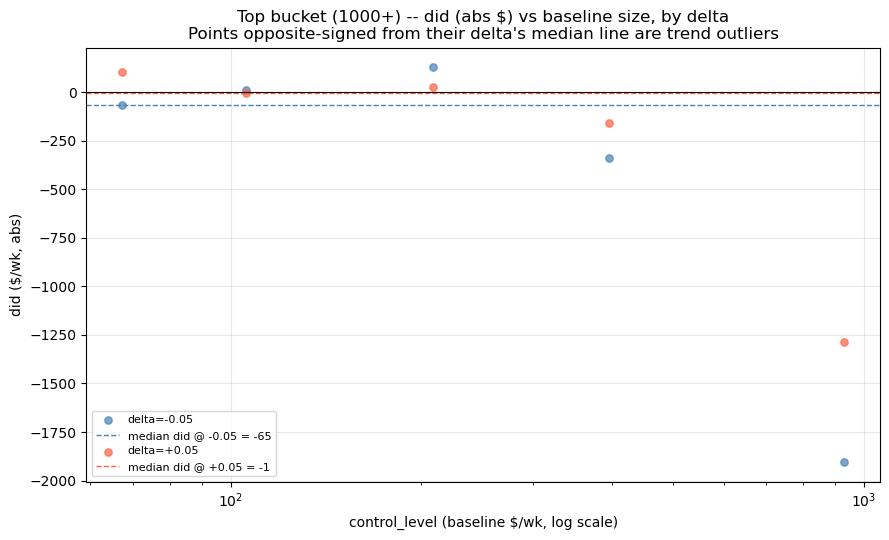

In [70]:
# ─── Top bucket — visual outlier check ────────────────────────────────────────
_top_bucket = BUCKET_ORDER[-1]
fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
sub = outlier_tables[_top_bucket]
colors = {-0.05: 'steelblue', 0.05: 'tomato'}
for d in sorted(sub['delta'].unique()):
    s = sub[sub['delta'] == d]
    ax.scatter(s['control_level'], s['did'], s=28, alpha=0.7,
               color=colors[d], label=f'delta={d:+.2f}')
    med = s['did'].median()
    ax.axhline(med, color=colors[d], linestyle='--', linewidth=1,
               label=f'median did @ {d:+.2f} = {med:,.0f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('control_level (baseline $/wk, log scale)')
ax.set_ylabel('did ($/wk, abs)')
ax.set_title(f"Top bucket ({_top_bucket}) -- did (abs $) vs baseline size, by delta\nPoints opposite-signed from their delta's median line are trend outliers")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
# ─── Full revenue pool — segment weights ──────────────────────────────────────
# Ranked_by_Revenue gives the experiment candidate universe.
# We use it only for relative weights (revenue share per segment), so the
# time scale of this file (monthly) does not affect the extrapolation. `rev_pool`
# was already loaded earlier, alongside the bucket reassignment.

rev_pool_st = rev_pool[rev_pool['Third_Party_Data_Provider_Id'] == 'sharethis'].copy()

total_pool_revenue = rev_pool_st['revenue'].sum()
rev_pool_st['pool_weight'] = rev_pool_st['revenue'] / total_pool_revenue

print(f"Sharethis segments in full pool: {len(rev_pool_st):,}")
print(f"Pool revenue (March, for weight computation only): ${total_pool_revenue:,.0f}")
print(f"Experiment segments covered: {pricing['Full_Path'].isin(rev_pool_st['Full_Path']).sum()} "
      f"of {len(rev_pool_st):,} "
      f"({pricing['Full_Path'].isin(rev_pool_st['Full_Path']).mean()*100:.1f}% of pool)")

Sharethis segments in full pool: 3,580
Pool revenue (March, for weight computation only): $181,022
Experiment segments covered: 957 of 3,580 (47.0% of pool)


In [72]:
rev_pool.groupby('Third_Party_Data_Provider_Id')['revenue'].sum()

Third_Party_Data_Provider_Id
dav2shreths     25433.86
sharethis      181021.59
Name: revenue, dtype: float64

In [73]:
rev_pool.head()

,Third_Party_Data_Provider_Id,Full_Path,revenue,rev_rank,bucket
0,sharethis,Global > people & society > social issues & advocacy > g...,13214.33,1,1000+
1,sharethis,B2B > Industry > Food Services,10172.36,2,1000+
2,sharethis,US > Health Interest > Dry Eyes,9899.08,3,1000+
3,sharethis,US > shopping > apparel > footwear,6607.92,4,1000+
4,sharethis,Global > Validated Demographic > Age > 18-44,3901.50,5,1000+


Revenue by geo × provider  (Ranked_by_Revenue, March — full candidate universe)
                 dav2shreths       sharethis         total   % of all
──────────────────────────────────────────────────────────────────────
  Global              25,433          69,417        94,850      45.9%
  US                       0          82,045        82,045      39.7%
  Unknown                  0          21,625        21,625      10.5%
  APAC                     0           4,716         4,716       2.3%
  Asia                     1           3,219         3,220       1.6%
──────────────────────────────────────────────────────────────────────
  total               25,434         181,022       206,455   100.0%

  ── ATE estimation scope ──
  Global sharethis  : $69,417
    33.6% of all revenue  (all providers, all geos)
    38.3% of total sharethis revenue

  Segment counts by geo × provider:
Third_Party_Data_Provider_Id  dav2shreths  sharethis
geo                                                

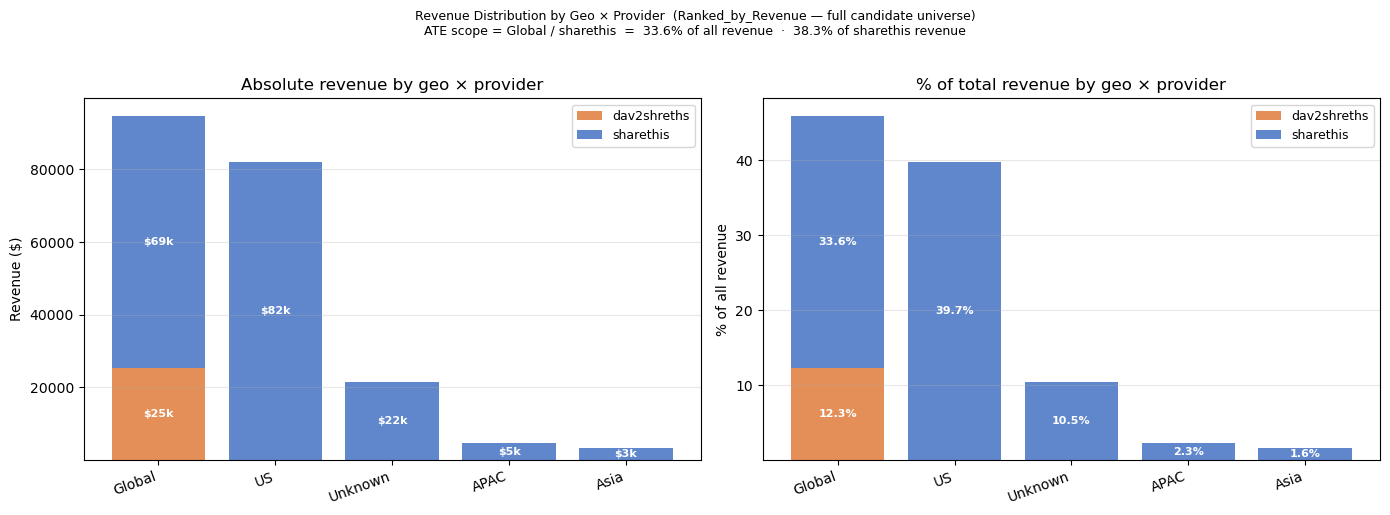

In [74]:

# ─── Revenue distribution by Geo × Provider (Ranked_by_Revenue — full universe) ─
# Shows what fraction of the total addressable revenue sits in each geo/provider
# cell — the baseline for understanding how representative the Global experiment is.

rev_pool_geo = rev_pool.copy()
rev_pool_geo['geo'] = rev_pool_geo['Full_Path'].apply(
    lambda x: get_geo(x.replace(" ", "").split(">"))
)

rev_by_gp = (
    rev_pool_geo.groupby(['geo', 'Third_Party_Data_Provider_Id'])['revenue']
    .sum()
    .unstack('Third_Party_Data_Provider_Id')
    .fillna(0)
)
rev_by_gp = rev_by_gp.loc[rev_by_gp.sum(axis=1).sort_values(ascending=False).index]

total_rev_all = rev_pool_geo['revenue'].sum()
total_rev_st  = rev_pool_st['revenue'].sum()
provs         = list(rev_by_gp.columns)
geos_rev      = list(rev_by_gp.index)

# Global sharethis specifically
global_st_rev = rev_pool_geo[
    (rev_pool_geo['geo'] == 'Global') &
    (rev_pool_geo['Third_Party_Data_Provider_Id'] == 'sharethis')
]['revenue'].sum()

print("Revenue by geo × provider  (Ranked_by_Revenue, March — full candidate universe)")
print(f"{'':12s}" + "".join(f"{c:>16s}" for c in provs) + f"{'total':>14s}  {'% of all':>9s}")
print("─" * (14 + 16 * len(provs) + 14 + 10))
for geo in geos_rev:
    row = rev_by_gp.loc[geo]
    tot = row.sum()
    print(f"  {geo:10s}" + "".join(f"{v:>16,.0f}" for v in row.values)
          + f"  {tot:>12,.0f}  {tot/total_rev_all*100:>8.1f}%")
print("─" * (14 + 16 * len(provs) + 14 + 10))
totals = rev_by_gp.sum()
print(f"  {'total':10s}" + "".join(f"{v:>16,.0f}" for v in totals.values)
      + f"  {total_rev_all:>12,.0f}   100.0%")

print(f"\n  ── ATE estimation scope ──")
print(f"  Global sharethis  : ${global_st_rev:,.0f}")
print(f"    {global_st_rev/total_rev_all*100:.1f}% of all revenue  (all providers, all geos)")
print(f"    {global_st_rev/total_rev_st*100:.1f}% of total sharethis revenue")
print(f"\n  Segment counts by geo × provider:")
seg_counts = (
    rev_pool_geo.groupby(['geo', 'Third_Party_Data_Provider_Id']).size()
    .unstack(fill_value=0)
    .loc[geos_rev]
)
print(seg_counts.to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_rev     = np.arange(len(geos_rev))
pcolors   = {'sharethis': '#4472C4', 'dav2shreths': '#E07B39'}

for ax_idx, (use_pct, ylabel, title) in enumerate([
    (False, 'Revenue ($)',       'Absolute revenue by geo × provider'),
    (True,  '% of all revenue', '% of total revenue by geo × provider'),
]):
    ax   = axes[ax_idx]
    data = rev_by_gp / (total_rev_all / 100) if use_pct else rev_by_gp
    bot  = np.zeros(len(geos_rev))
    for prov in provs:
        vals = data[prov].values
        ax.bar(x_rev, vals, bottom=bot, label=prov,
               color=pcolors.get(prov, 'gray'), alpha=0.85)
        for i, (v, b) in enumerate(zip(vals, bot)):
            thresh = 1.5 if use_pct else total_rev_all * 0.015
            if v > thresh:
                lbl = f'{v:.1f}%' if use_pct else f'${v/1000:.0f}k'
                ax.text(i, b + v / 2, lbl, ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bot += vals
    ax.set_xticks(x_rev)
    ax.set_xticklabels(geos_rev, rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Revenue Distribution by Geo × Provider  (Ranked_by_Revenue — full candidate universe)\n'
    f'ATE scope = Global / sharethis  =  {global_st_rev/total_rev_all*100:.1f}% of all revenue  ·  '
    f'{global_st_rev/total_rev_st*100:.1f}% of sharethis revenue',
    fontsize=9, y=1.02
)
plt.tight_layout()
plt.show()


## Panel revenue baseline & bucket setup — for ATE (below)

The ATE section below (Route 1: bucket-weighted ATT) needs exactly two things from this cell:

1. **`total_panel_weekly_rev`** — mean weekly `Data_Cost` for Global sharethis segments in the pre-period, restricted to the *same* 3-week window as `did`/`test` (`Week_Start_Date > test_df_start`), and built from `dat1_filled` (zero-filled) so numerator and denominator treat missing weeks identically.
2. **`did_impact['bucket']`** — bucket assignment (low/medium/high) joined onto `did`, used to group treatment effects by bucket for the bucket-weighted ATE.

(The earlier revenue-weighted extrapolation over experiment-only segments — weighted by `Ranked_by_Revenue` pool share — was dropped as redundant with the ATE section, which extrapolates to the full universe more rigorously, with bootstrap CIs.)

In [75]:
# ─── Panel revenue baseline + bucket assignment — setup for ATE (below) ──────
# Only two things are needed downstream (Route 1 ATE):
#   1. total_panel_weekly_rev -- dollar scale for extrapolation
#   2. did_impact['bucket']   -- bucket assignment used to group ATT by bucket

# ── bucket assignment ─────────────────────────────────────────────────────────
bucket_lookup = (
    pricing[pricing['Third_Party_Data_Provider_Id'] == 'sharethis']
    .drop_duplicates('Full_Path')
    .set_index('Full_Path')['bucket']
)
did_impact = did.copy()
did_impact['bucket'] = did_impact['Full_Path'].map(bucket_lookup)

# ── panel revenue baseline (Global sharethis only) ────────────────────────────
# Scoped to Global only -- the price change is only applied to Global segments.
# Built from dat1 (zero-filled, Advertiser_Category=='All' only), same source
# as `did`/`test`, so numerator and denominator treat missing weeks and
# categories identically -- using dat1_filled directly here would double-count
# across its 15 Advertiser_Category rows per segment/week. Restricted to the
# SAME pre-period window as `test`/`did` (Week_Start_Date > test_df_start).
pre_weeks_global = dat1[
    (dat1['Third_Party_Data_Provider_Id'] == 'sharethis') &
    (dat1['geo'] == 'Global') &
    (dat1['post'] == 0) &
    (dat1['Week_Start_Date'] > test_df_start)
]
weekly_rev_global = pre_weeks_global.groupby('Week_Start_Date')['Data_Cost'].sum()
total_panel_weekly_rev = apply_estimator(weekly_rev_global.values, 'mean')

_pre_week_dates = ', '.join(str(d)[:10] for d in sorted(weekly_rev_global.index))
print(f"total_panel_weekly_rev = ${total_panel_weekly_rev:,.0f}/wk  "
      f"-- the AVERAGE weekly revenue across the {weekly_rev_global.count()} pre-period weeks "
      f"({_pre_week_dates}), matching test_df_start={test_df_start}")


total_panel_weekly_rev = $10,638/wk  -- the AVERAGE weekly revenue across the 6 pre-period weeks (2026-04-13, 2026-04-20, 2026-04-27, 2026-05-04, 2026-05-11, 2026-05-18), matching test_df_start=2026-04-10


## ATE estimation — Route 1: bucket-weighted ATT

The experiment selected only **Global** geo segments, ranked by revenue within sharethis, then grouped into buckets of 120 groups (`n=120`, 3 segments per group). The DiD gives us ATT within each bucket. To estimate ATE, we need the bucket distribution of the *full* eligible universe — all Global sharethis segments in `Ranked_by_Revenue` — and weight accordingly:

```
ATE = Σ_bucket [ P(bucket | full universe) × ATT_bucket ]
```

Two weighting schemes are shown:
- **Segment-count weights**: each bucket's share of the total eligible segment count — treats every segment equally
- **Revenue weights**: each bucket's share of total eligible revenue — gives more influence to high-revenue buckets

If the experiment over-sampled high-revenue segments relative to the universe, the experiment-average ATT will differ from the ATE, and the revenue-weighted ATE will reveal whether the bias matters for the dollar impact estimate.

  SHARETHIS UNIVERSE  (Ranked_by_Revenue -- treatable segments only)
  geo           n_segs   % ST segs     revenue   % ST rev   % all rev
  -----------------------------------------------------------------
  US               831      23.2%    $  82,045     45.3%      39.7%
  Global         1,020      28.5%    $  69,417     38.3%      33.6%  <- experiment
  Unknown          499      13.9%    $  21,625     11.9%      10.5%
  APAC              12       0.3%    $   4,716      2.6%       2.3%
  Asia           1,218      34.0%    $   3,219      1.8%       1.6%
  -----------------------------------------------------------------
  total          3,580      100.0%    $ 181,022    100.0%      87.7%

  ATE scope: Global only  (1,020 segs, 28.5% of ST segs, 38.3% of ST rev)
  Panel $/wk (Global ST): $10,638

Global ST bucket distribution -- true population (n=1020 universe segs, from Ranked_by_Revenue):
        n_segs  seg_wt  avg_panel_rev_wk  rev_wt
bucket                                       

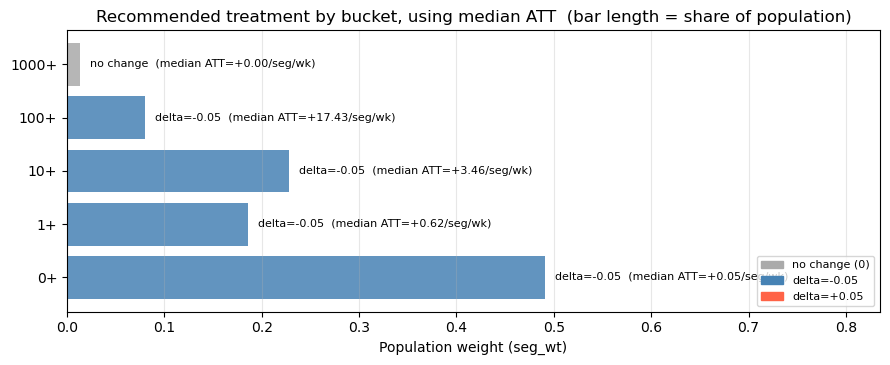


ATT  [Global sharethis, n_univ=1,020]  --  $/wk total (rel, 95% CI)  [n_boot=1000, trim=10%]
                                      ATT trimmed mean                          ATT median
delta=-0.05  $+1,924  (rel +0.181)  CI[+1,131, +2,744]  $+228  (rel +0.021)  CI[+76, +549]
delta=+0.05       $-629  (rel -0.059)  CI[-1,205, -87]       $+0  (rel +0.000)  CI[+0, +0]

ATE  [Global sharethis, n_univ=1,020]  --  $/wk total (rel, 95% CI)  [n_boot=1000, trim=10%]
                                       ATE trimmed mean                                  ATE median
delta=-0.05  $-2,030  (rel -0.191)  CI[-13,412, +5,523]  $+1,471  (rel +0.138)  CI[-24,151, +4,515]
delta=+0.05  $-6,202  (rel -0.583)  CI[-14,036, -1,016]    $-1,119  (rel -0.105)  CI[-19,362, +421]
Recommended   $+4,039  (rel +0.380)  CI[+1,752, +6,846]     $+2,377  (rel +0.223)  CI[+596, +3,695]

Baseline: $10,638/wk  (Global ST panel, pre-period)  --  rel = total_$/wk / baseline
Recommended = per-bucket best delta (incl. delta=0), 

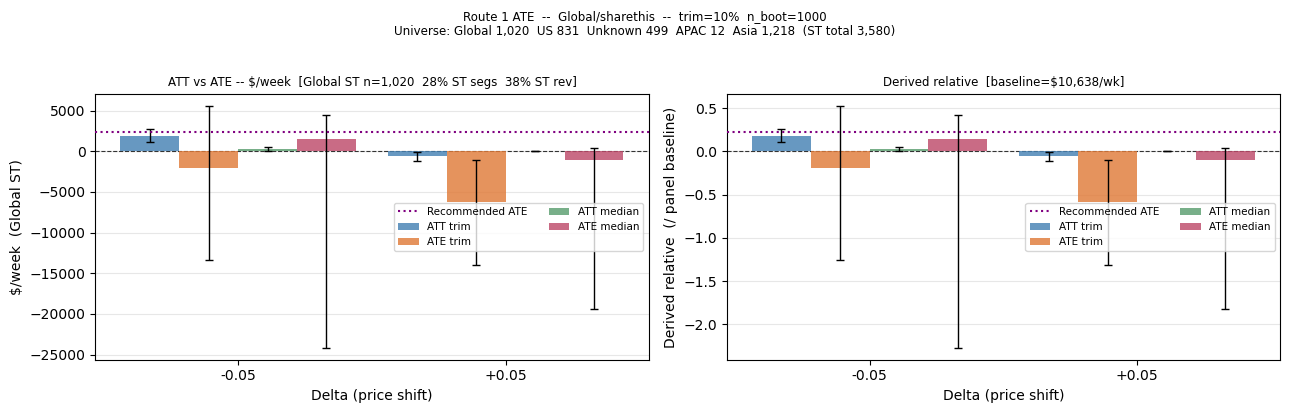

In [76]:
# Route 1 ATE: bucket-weighted ATT — Global / sharethis only
# ATT estimated three ways: raw mean (unstable), trimmed mean (10%), median.
# Raw mean shown for reference only — extreme outliers from near-zero control_level
# segments make it unreliable. Trimmed mean and median are the primary estimates.
#
# Formula:
#   ATT_bucket  = estimator(did) per bucket per delta         [$/seg/wk]
#   ATE         = sum_bucket  P(bucket) x ATT_bucket          [$/seg/wk]
#   total_$/wk  = ATE x n_univ
#   derived_rel = total_$/wk / total_panel_weekly_rev

N_BOOT = 1000
TRIM   = 0.10   # fraction trimmed from each tail
RNG    = np.random.default_rng(42)

# 1. Sharethis universe from Ranked_by_Revenue
st_rbr = rev_pool_geo[rev_pool_geo['Third_Party_Data_Provider_Id'] == 'sharethis'].copy()
geo_summary = (
    st_rbr.groupby('geo')
    .agg(n_segs=('Full_Path', 'count'), revenue=('revenue', 'sum'))
    .sort_values('revenue', ascending=False)
)
geo_summary['pct_st_segs'] = geo_summary['n_segs']  / geo_summary['n_segs'].sum()
geo_summary['pct_st_rev']  = geo_summary['revenue'] / geo_summary['revenue'].sum()
geo_summary['pct_all_rev'] = geo_summary['revenue'] / total_rev_all
total_st_segs = int(geo_summary['n_segs'].sum())
total_st_rev  = geo_summary['revenue'].sum()

print('=' * 75)
print('  SHARETHIS UNIVERSE  (Ranked_by_Revenue -- treatable segments only)')
print('=' * 75)
print(f"  {'geo':<10s}  {'n_segs':>8s}  {'% ST segs':>10s}  "
      f"{'revenue':>10s}  {'% ST rev':>9s}  {'% all rev':>10s}")
print('  ' + '-' * 65)
for geo, row in geo_summary.iterrows():
    marker = '  <- experiment' if geo == 'Global' else ''
    print(f"  {geo:<10s}  {int(row['n_segs']):>8,}  {row['pct_st_segs']:>9.1%}  "
          f"  ${row['revenue']:>8,.0f}  {row['pct_st_rev']:>8.1%}  {row['pct_all_rev']:>9.1%}" + marker)
print('  ' + '-' * 65)
print(f"  {'total':<10s}  {total_st_segs:>8,}  {'100.0%':>10s}  "
      f"  ${total_st_rev:>8,.0f}  {'100.0%':>8s}  {total_st_rev/total_rev_all:>9.1%}")
print(f"\n  ATE scope: Global only  ({int(geo_summary.loc['Global','n_segs']):,} segs, "
      f"{geo_summary.loc['Global','pct_st_segs']:.1%} of ST segs, "
      f"{geo_summary.loc['Global','pct_st_rev']:.1%} of ST rev)")
print(f"  Panel $/wk (Global ST): ${total_panel_weekly_rev:,.0f}")
print('=' * 75)

# 2. Universe bucket weights -- computed directly on rev_pool_geo (the full
# Ranked_by_Revenue universe), not on pricing's experiment candidates. This is
# what "seg_wt" for ATE should reflect: the true population's own bucket
# composition, not the (possibly skewed) subset that got recruited into the
# experiment. `bucket` was already assigned directly on `rev_pool` in the
# earlier reassignment cell and carried through into rev_pool_geo -- so this
# is the exact same rule, just evaluated over the full universe instead of
# pricing's ~2000-segment candidate list.
bkts = list(reversed(BUCKET_ORDER))
st_global_universe = rev_pool_geo[
    (rev_pool_geo['geo'] == 'Global') & (rev_pool_geo['Third_Party_Data_Provider_Id'] == 'sharethis')
]
n_by_bkt = st_global_universe.groupby('bucket').size().reindex(bkts).fillna(0).astype(int)
seg_wt   = n_by_bkt / n_by_bkt.sum()
n_univ   = int(geo_summary.loc['Global', 'n_segs'])

# revenue weight alongside seg_wt -- same buckets, but weighted by $ instead of
# segment count. Segment-heavy buckets (e.g. 0+) can carry very little of the
# total revenue, and vice versa for 1000+ -- both views are useful side by side.
# Average WEEKLY panel revenue per bucket -- same pre_weeks_global panel (dat1,
# zero-filled, Global sharethis, matching test_df_start) used for
# total_panel_weekly_rev above, just broken out by bucket instead of summed
# across all of them. These sum to ~total_panel_weekly_rev.
avg_panel_rev_by_bkt = (
    pre_weeks_global.groupby(['bucket', 'Week_Start_Date'])['Data_Cost'].sum()
    .groupby('bucket').mean()
    .reindex(bkts).fillna(0.0)
)

# rev_wt: revenue weight from Ranked_by_Revenue (monthly), shown as a plain
# fraction rather than alongside its raw dollar figure -- the raw monthly
# 'revenue' total per bucket isn't shown here since it's a different time
# scale than avg_panel_rev_wk (weekly) and comparing the two dollar figures
# directly invites a mix-up; the normalized weight doesn't have that problem.
rev_by_bkt = st_global_universe.groupby('bucket')['revenue'].sum().reindex(bkts).fillna(0.0)
rev_wt     = rev_by_bkt / rev_by_bkt.sum()

print(f"\nGlobal ST bucket distribution -- true population (n={n_univ} universe segs, from Ranked_by_Revenue):")
print(n_by_bkt.to_frame('n_segs').assign(
    seg_wt=seg_wt.round(4), avg_panel_rev_wk=avg_panel_rev_by_bkt.round(0), rev_wt=rev_wt.round(4)
).to_string())
print(f"(avg_panel_rev_wk sums to ${avg_panel_rev_by_bkt.sum():,.0f}/wk -- matches "
      f"total_panel_weekly_rev=${total_panel_weekly_rev:,.0f}/wk above; "
      f"rev_wt is from Ranked_by_Revenue (monthly), a separate source from the weekly panel)")

# For context only (NOT used for ATE weighting below): how does the
# experiment's own candidate pool compare to the true population above? Both
# are computed with the exact same bucket rule, so any gap here is really
# about which segments got recruited into the experiment, not a difference in
# definition.
st_global_px = pricing[
    (pricing['Third_Party_Data_Provider_Id'] == 'sharethis') & (pricing['geo'] == 'Global')
]
nonzero_deltas = st_global_px['delta'][st_global_px['delta'] != 0].abs().round(6)
min_delta      = nonzero_deltas.min()
one_delta_px   = st_global_px[st_global_px['delta'].abs().round(6) == min_delta]
n_by_bkt_experiment = one_delta_px.groupby('bucket').size().reindex(bkts).fillna(0).astype(int)
seg_wt_experiment   = n_by_bkt_experiment / n_by_bkt_experiment.sum()

bucket_compare = pd.DataFrame({
    'n_segs_population': n_by_bkt,
    'seg_wt_population': seg_wt.round(4),
    'n_segs_experiment': n_by_bkt_experiment,
    'seg_wt_experiment': seg_wt_experiment.round(4),
})
bucket_compare['wt_diff_pp'] = ((bucket_compare['seg_wt_experiment'] - bucket_compare['seg_wt_population']) * 100).round(2)
print(f"\nTrue population vs experiment candidate pool (nonzero-delta) bucket composition:")
print(bucket_compare.to_string())
print("(seg_wt used below for ATE is the true-population version, seg_wt_population above -- not the experiment's own)")

# 3. ATT by bucket x delta -- three estimators
did_sub = did_impact[did_impact['bucket'].notna()].copy()
deltas_nz = sorted([d for d in did_sub['delta'].unique() if d != 0.0])

def att_table(did_sub, estimator, bkts, deltas_nz, trim=TRIM):
    """Bucket x delta table of apply_estimator(did) -- the shared estimator
    primitive from the DiD-setup cell, reused here instead of a bespoke fn."""
    rows = {}
    for b in bkts:
        rows[b] = {}
        for d in deltas_nz:
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == d)]['did'].dropna().values
            rows[b][d] = apply_estimator(vals, estimator, trim) if len(vals) > 0 else np.nan
    return pd.DataFrame(rows).T.reindex(bkts)

att_mean   = att_table(did_sub, 'mean',   bkts, deltas_nz)
att_trim   = att_table(did_sub, 'trim',   bkts, deltas_nz)
att_median = att_table(did_sub, 'median', bkts, deltas_nz)

print(f"\nATT by bucket x delta  [$/seg/wk]")
print(f"  {'':12s}" + ''.join(f"  delta={d:+.2f}" for d in deltas_nz))
for b in bkts:
    vals_sub = did_sub[did_sub['bucket'] == b]
    print(f"  {b:<10s}  (seg_wt={seg_wt[b]:.4f})")
    for label, tbl in [('mean  ', att_mean), (f'trim{int(TRIM*100)}%', att_trim), ('median', att_median)]:
        row = f"    {label}  "
        for d in deltas_nz:
            v = tbl.loc[b, d]
            n = len(vals_sub[vals_sub['delta'] == d]['did'].dropna())
            row += f"  {v:>+8.4f} (n={n})  "
        print(row)

# 3b. Recommended delta by bucket -- for each bucket, compare its ATT at each
# treated delta against a FIXED ATT=0 for "do nothing". delta=0 isn't looked up
# in the table above (did is 0 by construction for control rows -- a group's
# control compared to itself -- so it's not a fitted effect, just the
# reference point every other delta is measured against). This matters for
# buckets where BOTH price moves come out negative: bucket 1000+ below shows
# both directions worse than doing nothing, so 0 is the recommended choice
# there specifically.
#
# Median is the primary / most robust estimator here: trimmed mean can fail
# silently on thin buckets (a 10% trim removes floor(0.1*n) points per tail,
# which rounds to 0 when n<10 -- e.g. bucket 1000+ -- so "trim10%" degenerates
# to the raw, outlier-sensitive mean exactly where robustness matters most).
# mean/trim are still shown alongside so a disagreement in "best delta" across
# estimators is visible rather than hidden -- that disagreement is itself a
# signal the recommendation for that bucket is estimator-sensitive.
def best_delta_for_bucket(tbl, b, deltas_nz):
    candidates = {0.0: 0.0}  # "do nothing" -- fixed reference, not looked up
    for d in deltas_nz:
        candidates[d] = tbl.loc[b, d]
    best_d = max(candidates, key=candidates.get)
    return best_d, candidates[best_d]

recommendation_rows = []
for b in bkts:
    best_median_d, best_median_v = best_delta_for_bucket(att_median, b, deltas_nz)
    best_trim_d,   _             = best_delta_for_bucket(att_trim,   b, deltas_nz)
    best_mean_d,   _             = best_delta_for_bucket(att_mean,   b, deltas_nz)
    recommendation_rows.append({
        'bucket': b,
        'seg_wt': seg_wt[b],
        'recommended_delta': best_median_d,
        'att_at_recommended': best_median_v,
        'best@trim': best_trim_d,
        'best@mean': best_mean_d,
        'estimators_agree': (best_median_d == best_trim_d == best_mean_d),
    })
rec_df = pd.DataFrame(recommendation_rows).set_index('bucket')
recommended_delta = rec_df['recommended_delta'].to_dict()

print(f"\nRecommended delta by bucket  ('do nothing' = fixed ATT 0, compared against both treated deltas):")
print(rec_df.to_string())

# Recommended ATE: each bucket weighted by its OWN best delta's ATT (median),
# instead of forcing the whole population to one uniform price change. This is
# the number used as "Recommended ATE" in the plot below.
recommended_ate = (rec_df['att_at_recommended'] * seg_wt.reindex(rec_df.index)).sum()
rec_tot, _, rec_rel = relative_did(recommended_ate, scale=n_univ, baseline=total_panel_weekly_rev)

# ── neat comparison: recommended vs uniform delta, all three estimators ──────
# "Recommended" here recomputes the per-bucket best delta separately for each
# estimator (not just reusing median's choice) -- so this also doubles as a
# cross-estimator sanity check: if mean/trim ever picked different deltas than
# median for enough buckets to matter, their "Recommended" row would diverge
# from median's, on top of the value it computes at that delta.
def _scenario_values(att_tbl):
    best_att = pd.Series({b: best_delta_for_bucket(att_tbl, b, deltas_nz)[1] for b in bkts})
    scenarios = {'Recommended (per-bucket best delta)': (best_att * seg_wt.reindex(bkts)).sum()}
    for d in deltas_nz:
        scenarios[f'Uniform delta={d:+.2f} for everyone'] = (att_tbl[d] * seg_wt).sum()
    return scenarios

_estimators = [('mean', att_mean), (f'trim{int(TRIM*100)}%', att_trim), ('median', att_median)]
_scenario_names = list(_scenario_values(att_median).keys())  # same keys for every estimator

comparison = {}
for est_name, tbl in _estimators:
    seg_vals = pd.Series(_scenario_values(tbl))
    comparison[est_name] = pd.DataFrame({
        '$/seg/wk': seg_vals,
        '$/wk':     seg_vals * n_univ,
        'rel':      seg_vals * n_univ / total_panel_weekly_rev,
    })

LABEL_W, BLOCK_W = 36, 31
print(f"\nRecommended ATE vs uniform delta -- {' / '.join(est_name for est_name, _ in _estimators)}:")
print(' ' * LABEL_W + ''.join(f"{est_name:^{BLOCK_W}s}" for est_name, _ in _estimators))
print(' ' * LABEL_W + ''.join(f"{'$/seg/wk':>9s} {'$/wk':>11s} {'rel':>8s} " for _ in _estimators))
print('-' * (LABEL_W + BLOCK_W * len(_estimators)))
for scenario in _scenario_names:
    row = f"{scenario:<{LABEL_W}s}"
    for est_name, _ in _estimators:
        seg_v = comparison[est_name].loc[scenario, '$/seg/wk']
        tot_v = comparison[est_name].loc[scenario, '$/wk']
        rel_v = comparison[est_name].loc[scenario, 'rel']
        row += f"{seg_v:>+9.2f} ${tot_v:>+9,.0f} {rel_v:>+7.3f} "
    print(row)
print(f"\n(median's \"Recommended\" row = {recommended_ate:+.4f} $/seg/wk -> ${rec_tot:,.0f}/wk "
      f"(rel={rec_rel:+.3f}) -- this is what's plotted as \"Recommended ATE\" below)")

# ── visual: recommended treatment by bucket ───────────────────────────────────
# Horizontal bar per bucket (ordered low-to-high revenue), colored by the
# recommended action, length = population weight -- shows both WHAT to do and
# HOW MUCH of the population it covers at a glance; more legible than the
# table above for a quick read.
_action_colors = {d: ('tomato' if d > 0 else 'steelblue') for d in deltas_nz}
_action_colors[0.0] = '#AAAAAA'
_plot_buckets = BUCKET_ORDER  # ascending low -> high revenue

fig, ax = plt.subplots(figsize=(9, 0.55 * len(_plot_buckets) + 1))
for i, b in enumerate(_plot_buckets):
    d = recommended_delta[b]
    ax.barh(i, seg_wt[b], color=_action_colors[d], alpha=0.85)
    action_label = 'no change' if d == 0.0 else f'delta={d:+.2f}'
    ax.text(seg_wt[b] + seg_wt.max() * 0.02, i,
            f"{action_label}  (median ATT={rec_df.loc[b, 'att_at_recommended']:+.2f}/seg/wk)",
            va='center', fontsize=8)
ax.set_yticks(range(len(_plot_buckets))); ax.set_yticklabels(_plot_buckets)
ax.set_xlabel('Population weight (seg_wt)')
ax.set_title('Recommended treatment by bucket, using median ATT  (bar length = share of population)')
ax.set_xlim(0, seg_wt.max() * 1.7)
ax.grid(axis='x', alpha=0.3)
_legend_deltas = [0.0] + deltas_nz
ax.legend(
    [plt.Rectangle((0, 0), 1, 1, color=_action_colors[d]) for d in _legend_deltas],
    ['no change (0)' if d == 0.0 else f'delta={d:+.2f}' for d in _legend_deltas],
    fontsize=8, loc='lower right'
)
plt.tight_layout()
plt.show()

# 4. ATE point estimates -- trimmed mean and median only
def ate_from_att(att_tbl, seg_wt, deltas_nz):
    return (att_tbl[deltas_nz].T * seg_wt).T.sum(skipna=False)

ate_trim   = ate_from_att(att_trim,   seg_wt, deltas_nz)
ate_median = ate_from_att(att_median, seg_wt, deltas_nz)

# 5. Bootstrap 95% CIs
def boot_ate(did_sub, seg_wt, bkts, delta, n_boot, rng, fn):
    samples = []
    for _ in range(n_boot):
        ate_b = 0.0
        for b in bkts:
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == delta)]['did'].dropna().values
            if len(vals) == 0: continue
            ate_b += seg_wt[b] * fn(rng.choice(vals, size=len(vals), replace=True))
        samples.append(ate_b)
    return np.percentile(samples, [2.5, 97.5])

def boot_att_overall(did_sub, delta, n_boot, rng, fn):
    vals  = did_sub[did_sub['delta'] == delta]['did'].dropna().values
    boots = [fn(rng.choice(vals, size=len(vals), replace=True)) for _ in range(n_boot)]
    return np.percentile(boots, [2.5, 97.5])

def boot_recommended_ate(did_sub, seg_wt, bkts, recommended_delta, n_boot, rng, fn):
    """Same idea as boot_ate, but each bucket resamples at ITS OWN recommended
    delta instead of one delta for everyone. Buckets recommended delta=0 ("do
    nothing") contribute exactly 0 with no resampling -- did is fixed at 0 by
    construction for control rows, there's no distribution to bootstrap."""
    samples = []
    for _ in range(n_boot):
        ate_b = 0.0
        for b in bkts:
            d = recommended_delta[b]
            if d == 0.0:
                continue
            vals = did_sub[(did_sub['bucket'] == b) & (did_sub['delta'] == d)]['did'].dropna().values
            if len(vals) == 0: continue
            ate_b += seg_wt[b] * fn(rng.choice(vals, size=len(vals), replace=True))
        samples.append(ate_b)
    return np.percentile(samples, [2.5, 97.5])

ci = {}  # keyed by (estimator, 'att'/'ate', delta)
for d in deltas_nz:
    for est_name in ['trim', 'median']:
        fn = (lambda v, e=est_name: apply_estimator(v, e, TRIM))
        ci[(est_name, 'att', d)] = boot_att_overall(did_sub, d, N_BOOT, RNG, fn)
        ci[(est_name, 'ate', d)] = boot_ate(did_sub, seg_wt, bkts, d, N_BOOT, RNG, fn)

rec_ci = boot_recommended_ate(did_sub, seg_wt, bkts, recommended_delta, N_BOOT, RNG,
                               lambda v: apply_estimator(v, 'median', TRIM))

# Same recommendation, but using trim10% as the per-bucket estimator throughout
# (its own best-delta choice per bucket, not just reusing median's) -- lets the
# summary table below show "Recommended" as a 3rd column parallel to the two
# deltas, for both the trimmed-mean and median rows.
recommended_delta_trim = {b: best_delta_for_bucket(att_trim, b, deltas_nz)[0] for b in bkts}
recommended_ate_trim = sum(
    seg_wt[b] * best_delta_for_bucket(att_trim, b, deltas_nz)[1] for b in bkts
)
rec_ci_trim = boot_recommended_ate(did_sub, seg_wt, bkts, recommended_delta_trim, N_BOOT, RNG,
                                    lambda v: apply_estimator(v, 'trim', TRIM))

att_trim_overall   = did_sub.groupby('delta')['did'].apply(lambda v: apply_estimator(v.dropna().values, 'trim'))
att_median_overall = did_sub.groupby('delta')['did'].apply(lambda v: apply_estimator(v.dropna().values, 'median'))

# 6. Summary table -- as a DataFrame instead of hand-built fixed-width blocks.
# With 3 scenario columns (2 deltas + Recommended) x 4 metrics each, the manual
# print(..., end='') version wrapped/misaligned on typical terminal widths.
# Folding $/wk + rel + CI into one compact string per cell keeps every row to
# a single coherent line ($/seg/wk is dropped here -- it's in the ATT-by-bucket
# table above, and $/wk is the number that matters for a go/no-go decision).
summary_rows = [
    ('ATT trimmed mean',  'trim',   'att', att_trim_overall,   None,                 None),
    ('ATE trimmed mean',  'trim',   'ate', ate_trim,           recommended_ate_trim, rec_ci_trim),
    ('ATT median',        'median', 'att', att_median_overall, None,                 None),
    ('ATE median',        'median', 'ate', ate_median,         recommended_ate,      rec_ci),
]

def _fmt_cell(v, ci_pair, n_univ, baseline):
    if v is None:
        return 'n/a (ATT)'
    tot, _, rel = relative_did(v, scale=n_univ, baseline=baseline)
    if ci_pair is None:
        return f"${tot:+,.0f}  (rel {rel:+.3f})"
    lo, hi = ci_pair[0] * n_univ, ci_pair[1] * n_univ
    return f"${tot:+,.0f}  (rel {rel:+.3f})  CI[{lo:+,.0f}, {hi:+,.0f}]"

# Split into two narrower DataFrames (ATT, ATE) instead of one wide combined
# table -- ATT has no "Recommended" value at all (it's a per-bucket blend,
# which only makes sense once you're already computing ATE), so this also
# drops the "n/a (ATT)" filler cells entirely rather than just splitting width.
_att_table, _ate_table = {}, {}
for label, est, kind, series, rec_val, rec_ci_pair in summary_rows:
    row = {}
    for d in deltas_nz:
        v = series.get(d, float('nan'))
        row[f'delta={d:+.2f}'] = _fmt_cell(v, ci[(est, kind, d)], n_univ, total_panel_weekly_rev)
    if kind == 'att':
        _att_table[label] = row
    else:
        row['Recommended'] = _fmt_cell(rec_val, rec_ci_pair, n_univ, total_panel_weekly_rev)
        _ate_table[label] = row

att_df = pd.DataFrame(_att_table)
ate_df = pd.DataFrame(_ate_table)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 60)

print(f"\nATT  [Global sharethis, n_univ={n_univ:,}]  --  $/wk total (rel, 95% CI)  "
      f"[n_boot={N_BOOT}, trim={int(TRIM*100)}%]")
print(att_df.to_string())

print(f"\nATE  [Global sharethis, n_univ={n_univ:,}]  --  $/wk total (rel, 95% CI)  "
      f"[n_boot={N_BOOT}, trim={int(TRIM*100)}%]")
print(ate_df.to_string())

print(f"\nBaseline: ${total_panel_weekly_rev:,.0f}/wk  (Global ST panel, pre-period)  --  rel = total_$/wk / baseline")
print(f"Recommended = per-bucket best delta (incl. delta=0), blended by seg_wt -- "
      f"trim column uses each bucket's trim-best delta, median column uses each bucket's median-best delta")
# 7. Extrapolation guide
# "Recommended" is added as a 3rd column block alongside the two deltas -- same
# per-seg-wk rate (recommended_ate_trim / recommended_ate, the per-bucket
# blended ATE from section 3b/6 above) extrapolated by each geo's own n_segs.
# Carries the same "assumes same price elasticity" caveat as the delta columns:
# it assumes non-Global geos would respond the way Global's buckets did, both
# in ATT magnitude AND in which delta (incl. "do nothing") each bucket prefers.
print(f"\n{'':=>78}")
print(f"  Extrapolation  (ATE $/seg/wk x geo n_segs -- assumes same price elasticity)")
print(f"  Using trimmed mean ATE as primary estimate")
print(f"{'':=>78}")
print(f"  {'geo':<10s}  {'n_segs':>7s}  ", end='')
for d in deltas_nz:
    print(f" {'delta='+f'{d:+.2f}':^28s}  ", end='')
print(f" {'Recommended':^28s}  ")
print(f"  {'':10s}  {'':7s}  ", end='')
for d in deltas_nz:
    print(f"  {'trim $/wk':>12s}  {'median $/wk':>12s}  ", end='')
print(f"  {'trim $/wk':>12s}  {'median $/wk':>12s}  ")
print('  ' + '-' * 98)

for geo, row in geo_summary.iterrows():
    n    = int(row['n_segs'])
    line = f"  {geo:<10s}  {n:>7,}  "
    for d in deltas_nz:
        vt = ate_trim.get(d, float('nan'))   * n
        vm = ate_median.get(d, float('nan')) * n
        line += f"  ${vt:>10,.0f}  ${vm:>10,.0f}  "
    rt, rm = recommended_ate_trim * n, recommended_ate * n
    line += f"  ${rt:>10,.0f}  ${rm:>10,.0f}  "
    if geo == 'Global':
        line += ' <- estimated from experiment'
    print(line)

print('  ' + '-' * 98)
line = f"  {'all ST':<10s}  {total_st_segs:>7,}  "
for d in deltas_nz:
    vt = ate_trim.get(d, float('nan'))   * total_st_segs
    vm = ate_median.get(d, float('nan')) * total_st_segs
    line += f"  ${vt:>10,.0f}  ${vm:>10,.0f}  "
rt, rm = recommended_ate_trim * total_st_segs, recommended_ate * total_st_segs
line += f"  ${rt:>10,.0f}  ${rm:>10,.0f}  "
print(line)
print(f"{'':=>78}")

# 8. Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x_pos   = np.arange(len(deltas_nz))
xlabels = [f'{d:+.2f}' for d in deltas_nz]
bw      = 0.22

plot_ests = [
    ('ATT trim',   'trim',   'att', att_trim_overall,   'steelblue',  -1),
    ('ATE trim',   'trim',   'ate', ate_trim,            '#E07B39',     0),
    ('ATT median', 'median', 'att', att_median_overall,  '#5A9E6F',     1),
    ('ATE median', 'median', 'ate', ate_median,          '#BE4A6A',     2),
]

global_pct_st_segs = geo_summary.loc['Global', 'pct_st_segs']
global_pct_st_rev  = geo_summary.loc['Global', 'pct_st_rev']

for ax_idx, (scale, ylabel, title_str) in enumerate([
    (n_univ,
     '$/week  (Global ST)',
     f'ATT vs ATE -- $/week  [Global ST n={n_univ:,}  '
     f'{global_pct_st_segs:.0%} ST segs  {global_pct_st_rev:.0%} ST rev]'),
    (n_univ / total_panel_weekly_rev,
     'Derived relative  (/ panel baseline)',
     f'Derived relative  [baseline=${total_panel_weekly_rev:,.0f}/wk]'),
]):
    ax = axes[ax_idx]
    offsets = np.array([-1.5, -0.5, 0.5, 1.5])
    for (label, est, kind, series, col, _), offset in zip(plot_ests, offsets):
        vals = [series.get(d, float('nan')) * scale for d in deltas_nz]
        lo_  = [(series.get(d, float('nan')) - ci[(est, kind, d)][0]) * scale for d in deltas_nz]
        hi_  = [(ci[(est, kind, d)][1] - series.get(d, float('nan'))) * scale for d in deltas_nz]
        xpos = x_pos + offset * bw
        ax.bar(xpos, vals, bw, label=label, color=col, alpha=0.82, zorder=3)
        ax.errorbar(xpos, vals, yerr=[lo_, hi_], fmt='none', color='black',
                    capsize=3, lw=1, zorder=4)
    ax.axhline(0, color='#333', lw=0.8, ls='--')
    # Recommended ATE (per-bucket best delta, section 3b above) -- same scale
    # conversion as the bars: rec_tot for the $/week panel, rec_rel for the
    # derived-relative panel (rec_rel already = recommended_ate * n_univ / total_panel_weekly_rev).
    rec_line_val = rec_tot if ax_idx == 0 else rec_rel
    ax.axhline(rec_line_val, color='purple', lw=1.5, ls=':', zorder=5, label='Recommended ATE')
    ax.set_xticks(x_pos); ax.set_xticklabels(xlabels)
    ax.set_xlabel('Delta (price shift)'); ax.set_ylabel(ylabel)
    ax.set_title(title_str, fontsize=8.5)
    ax.legend(fontsize=7.5, ncol=2); ax.grid(axis='y', alpha=0.3)

other_geos = '  '.join(
    f'{g} {int(r["n_segs"]):,}' for g, r in geo_summary.iterrows() if g != 'Global'
)
fig.suptitle(
    f'Route 1 ATE  --  Global/sharethis  --  trim={int(TRIM*100)}%  n_boot={N_BOOT}\n'
    f'Universe: Global {int(geo_summary.loc["Global","n_segs"]):,}  '
    + other_geos + f'  (ST total {total_st_segs:,})',
    fontsize=8.5, y=1.02
)
plt.tight_layout()
plt.show()


# Impact on Impressions and eCPM

Price changes affect two demand-side signals beyond revenue:

- **`Effective_Impression_Count`** — how many impressions buyers generated from the segment. A price increase compresses demand (fewer impressions); a decrease expands it.
- **eCPM** (`Data_Cost * 1000 / Effective_Impression_Count`) — the effective cost per thousand impressions. This captures price elasticity: if buyers reduce usage by more than the price increase, eCPM can still fall.

**Method:** absolute DiD only (pre→post change minus the control group's trend). A per-segment relative (/ control pre-level) version isn't computed here, for the same reason `did_rel` was dropped from the revenue-DiD section above: dividing by a segment's own control-group pre-period level is noisy whenever that level is near zero, which zero-filling missing weeks (`dat1_filled`, above) makes more common, not less. See `desc_stats_agg_rel` in the revenue-DiD section for the aggregate ratio-of-aggregates alternative if a relative view is needed.

In [77]:
# ── Build DiD for Effective_Impression_Count and eCPM ─────────────────────────
# Mirrors the revenue DiD: segment-level pre/post means, then subtract the
# control group's trend to isolate the treatment effect. Absolute DiD only --
# see the markdown above for why no per-segment relative version is computed.

# Segment × period means (averaging over weeks within each pre/post window)
vol_means = (
    test
    .groupby(['group', 'Full_Path', 'delta', 'post'])
    [['Data_Cost', 'Effective_Impression_Count']]
    .mean()
)
# eCPM at the segment × period level; EIC = 0 produces inf → replaced with NaN
vol_means['eCPM'] = (
    vol_means['Data_Cost'] * 1000 / vol_means['Effective_Impression_Count']
).replace([np.inf, -np.inf], np.nan)

# Pivot pre / post into columns
vol_pre    = vol_means.xs(0, level='post')
vol_post   = vol_means.xs(1, level='post')
vol_joined = vol_pre.join(vol_post, lsuffix='_pre', rsuffix='_post').reset_index()

# Pre→post change per segment
vol_joined['chg_eic']  = (vol_joined['Effective_Impression_Count_post']
                          - vol_joined['Effective_Impression_Count_pre'])
vol_joined['chg_ecpm'] = vol_joined['eCPM_post'] - vol_joined['eCPM_pre']

# Control group's mean trend (to subtract)
ctrl_chg = (
    vol_joined[vol_joined['delta'] == 0]
    .groupby('group')[['chg_eic', 'chg_ecpm']]
    .mean()
    .rename(columns={'chg_eic': 'ctrl_chg_eic', 'chg_ecpm': 'ctrl_chg_ecpm'})
)

did_vol = (
    vol_joined
    .join(ctrl_chg, on='group')
    .dropna(subset=['ctrl_chg_eic'])
    .copy()
)

# Absolute DiD
did_vol['did_eic']  = did_vol['chg_eic']  - did_vol['ctrl_chg_eic']
did_vol['did_ecpm'] = did_vol['chg_ecpm'] - did_vol['ctrl_chg_ecpm']

# Bucket labels (re-derived here so this cell is self-contained)
_bucket_map = (
    pricing[pricing['Third_Party_Data_Provider_Id'] == 'sharethis']
    .drop_duplicates('Full_Path')
    .set_index('Full_Path')['bucket']
)
did_vol = did_vol.join(_bucket_map, on='Full_Path')

# Revenue DiD — computed directly from vol_joined (same Data_Cost columns,
# no cross-dataframe join needed, avoids any key-matching fragility). This is
# an independent recomputation, not a merge from the earlier `did` dataframe --
# same segments, same formula, kept separate so this section is self-contained.
did_vol['chg_rev'] = did_vol['Data_Cost_post'] - did_vol['Data_Cost_pre']
ctrl_chg_rev = (
    did_vol[did_vol['delta'] == 0]
    .groupby('group')['chg_rev']
    .mean()
    .rename('ctrl_chg_rev')
)
did_vol = did_vol.join(ctrl_chg_rev, on='group')
did_vol['did_rev'] = did_vol['chg_rev'] - did_vol['ctrl_chg_rev']

# Trimming fraction used throughout this section (matches the ATE analysis above)
_TRIM = 0.10
from scipy.stats import trim_mean as _trim_mean

def desc_stats_trim(df, col, trim=_TRIM):
    """Like desc_stats but uses trimmed mean as the primary point estimate."""
    rows = []
    for d in sorted(df['delta'].unique()):
        vals = df[df['delta'] == d][col].dropna().values
        _, p_t    = stats.ttest_1samp(vals, popmean=0)
        _, p_trim = ttest_trimmed(vals)
        p_wilcox  = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        rows.append({
            'delta':     d,
            'n':         len(vals),
            'trim_mean': round(float(_trim_mean(vals, trim)), 3),
            'std':       round(float(vals.std()), 3),
            'cdf0':      round(float((vals <= 0).mean()), 3),
            'p5':  q(0.05), 'q25': q(0.25), 'median': q(0.50),
            'q75': q(0.75), 'p95': q(0.95),
            'p_t':      round(float(p_t),      4),
            'p_trim':   round(float(p_trim),   4),
            'p_wilcox': round(float(p_wilcox), 4),
        })
    return pd.DataFrame(rows)

_sum_cols = ['did_rev', 'did_eic', 'did_ecpm']
print(f"Segments: {len(did_vol):,}  |  eCPM computable (EIC > 0): {did_vol['did_ecpm'].notna().sum():,}")
print(f"Trimmed mean (trim={_TRIM}) by delta:")
did_vol.groupby('delta')[_sum_cols].apply(
    lambda g: g.apply(lambda c: round(_trim_mean(c.dropna().values, _TRIM), 4))
)


Segments: 957  |  eCPM computable (EIC > 0): 638
Trimmed mean (trim=0.1) by delta:


,did_rev,did_eic,did_ecpm
delta,,,
-0.05,1.8862,12129.8392,-0.0098
0.00,0.0000,0.0000,0.0000
0.05,-0.6164,-6967.4831,0.0233



  Revenue (Data_Cost)
 delta   n  trim_mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 319      1.886 111.856 0.323  -7.631 -0.011   0.223 3.832 31.470 0.8268  0.0000    0.0000
  0.00 319      0.000   0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
  0.05 319     -0.616  75.486 0.608 -22.820 -1.183   0.000 0.479 12.772 0.1043  0.0001    0.0529

  Effective Impression Count
 delta   n  trim_mean        std  cdf0          p5        q25  median       q75        p95    p_t  p_trim  p_wilcox
 -0.05 319  12129.839 311564.674 0.282  -53365.633     -3.167  1798.0 25111.500 214901.800 0.4490     0.0    0.0000
  0.00 319      0.000      0.000 1.000       0.000      0.000     0.0     0.000      0.000    NaN     NaN    1.0000
  0.05 319  -6967.483 213506.817 0.624 -218576.300 -12712.417    -5.0   968.167  45293.467 0.0014     0.0    0.0001

  eCPM  (Data_Cost * 1000 / EIC)
 delta   n  trim_mean   std  cdf0     p5    q25  median   q75

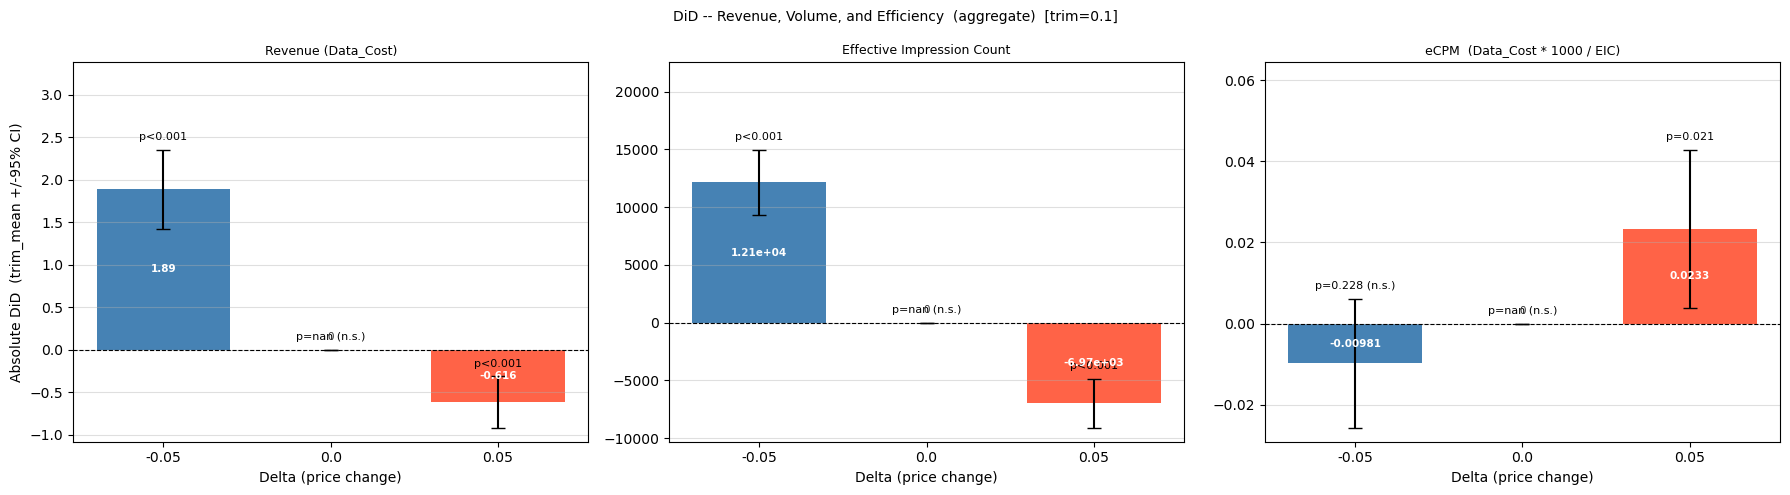

In [78]:
# ── Aggregate summary: stats table + 1x3 chart ──────────────────────────────
# Columns: Revenue (Data_Cost) | EIC | eCPM -- absolute DiD only (see markdown
# above for why no per-segment relative version is computed).
_all_metrics = [
    (did_vol, 'did_rev',  'Revenue (Data_Cost)'),
    (did_vol, 'did_eic',  'Effective Impression Count'),
    (did_vol, 'did_ecpm', 'eCPM  (Data_Cost * 1000 / EIC)'),
]

for df, abs_col, name in _all_metrics:
    print(f"\n{'=' * 65}")
    print(f"  {name}")
    print(f"{'=' * 65}")
    print(desc_stats_trim(df, abs_col).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for col_idx, (df, abs_col, name) in enumerate(_all_metrics):
    ax = axes[col_idx]
    plot_did_bars(ax, df, abs_col, metric='mean', trim=_TRIM)
    ax.set_xlabel('Delta (price change)')
    ax.set_title(name, fontsize=9)
    if col_idx == 0:
        ax.set_ylabel('Absolute DiD  (trim_mean +/-95% CI)')

fig.suptitle(f'DiD -- Revenue, Volume, and Efficiency  (aggregate)  [trim={_TRIM}]', fontsize=10)
plt.tight_layout()
plt.show()


## By bucket

Same DiD for impressions and eCPM broken out by revenue bucket (low / medium / high). Buckets reflect the experiment design's revenue ranking within Global sharethis segments. High-bucket segments are higher-revenue and may exhibit different price elasticity.



  Bucket: 0+

  -- Revenue (Data_Cost)  (n=471) --
 delta   n  trim_mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 157      0.356 8.115 0.318 -0.866  0.000   0.047 0.758 6.909 0.4738  0.0000    0.0000
  0.00 157      0.000 0.000 1.000  0.000  0.000   0.000 0.000 0.000    NaN     NaN    1.0000
  0.05 157      0.012 7.706 0.637 -2.403 -0.032   0.000 0.040 1.797 0.4795  0.5585    0.8401

  -- Effective Impression Count  (n=471) --
 delta   n  trim_mean        std  cdf0       p5      q25  median      q75       p95    p_t  p_trim  p_wilcox
 -0.05 157   2167.169 130482.548 0.261 -19005.5    0.000 436.833 4124.167 35623.367 0.6512  0.0000    0.0000
  0.00 157      0.000      0.000 1.000      0.0    0.000   0.000    0.000     0.000    NaN     NaN    1.0000
  0.05 157   -144.509 127234.517 0.599 -20529.3 -231.167   0.000  192.667  9683.933 0.2327  0.2915    0.7757

  -- eCPM  (Data_Cost * 1000 / EIC)  (n=471) --
 delta  n  trim_mean   std  cdf0     p5    q25

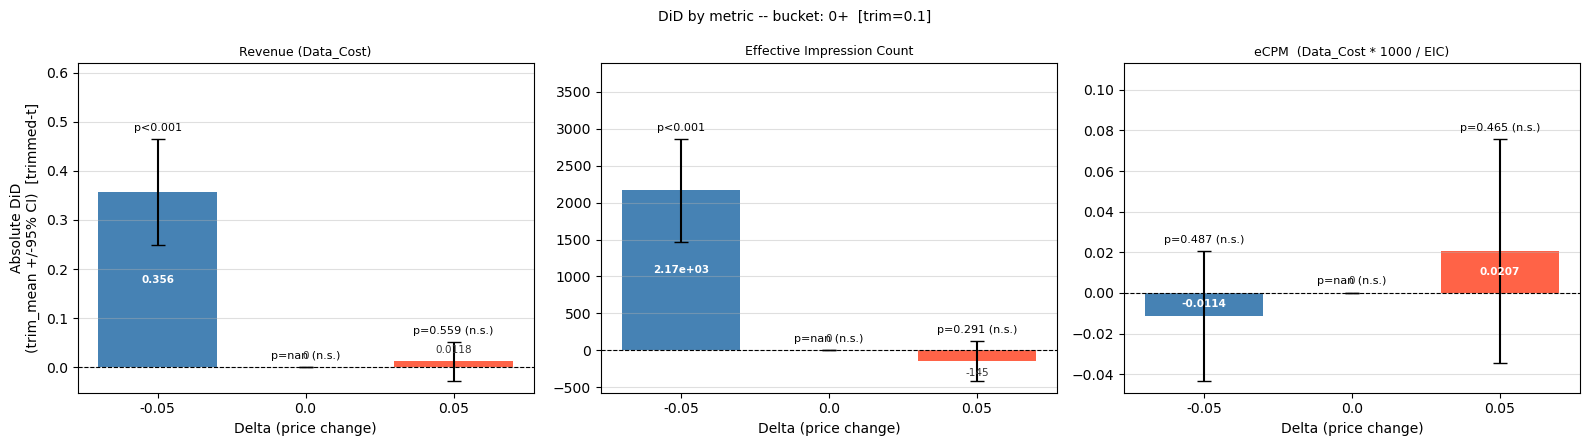

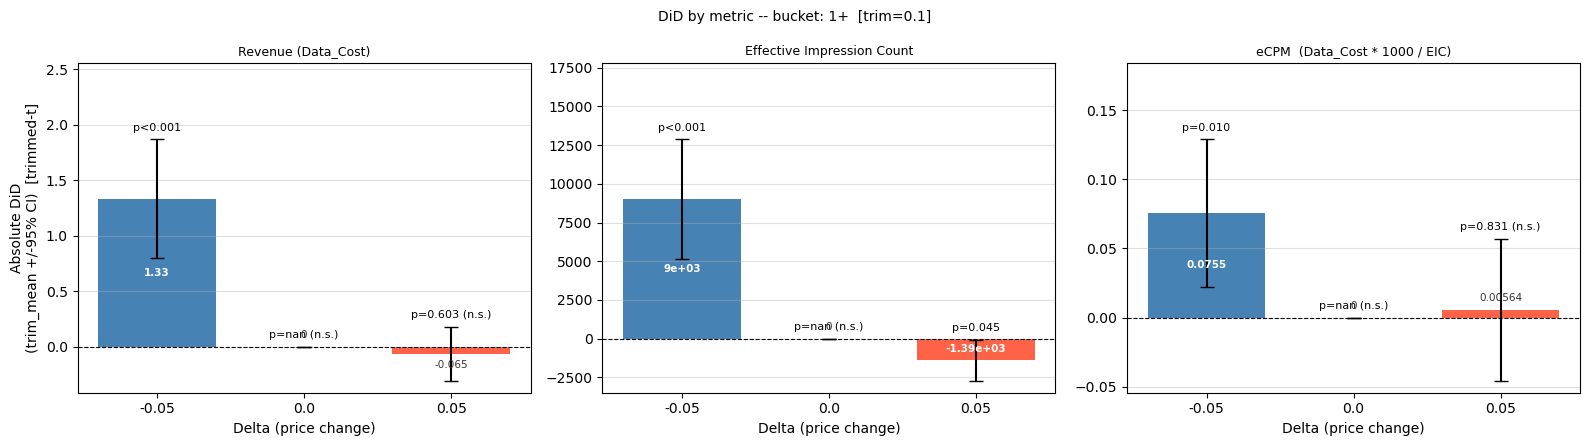

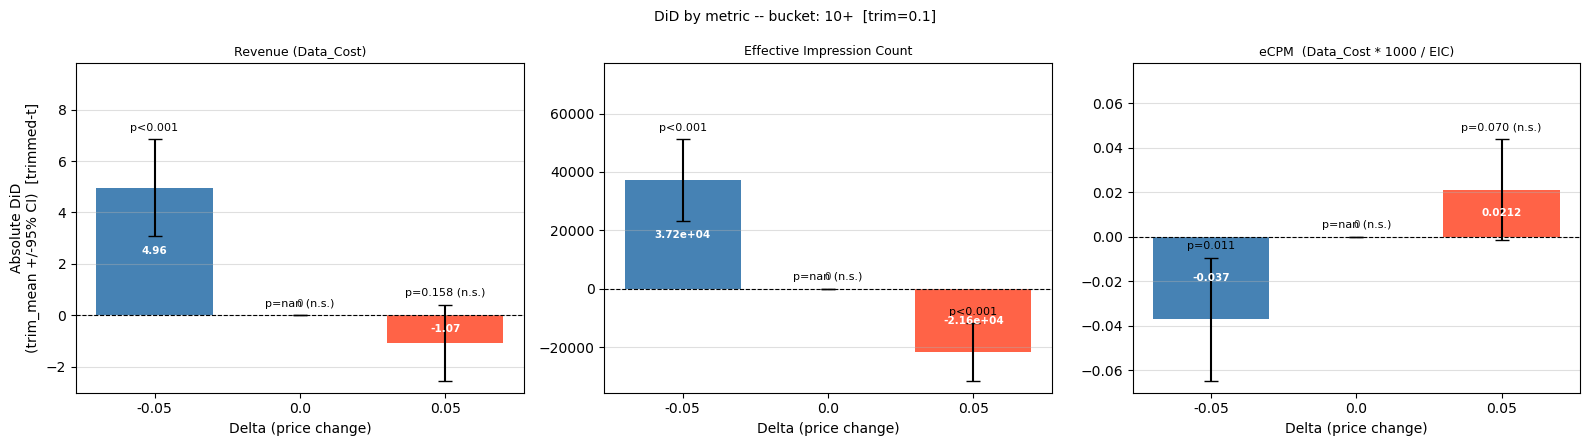

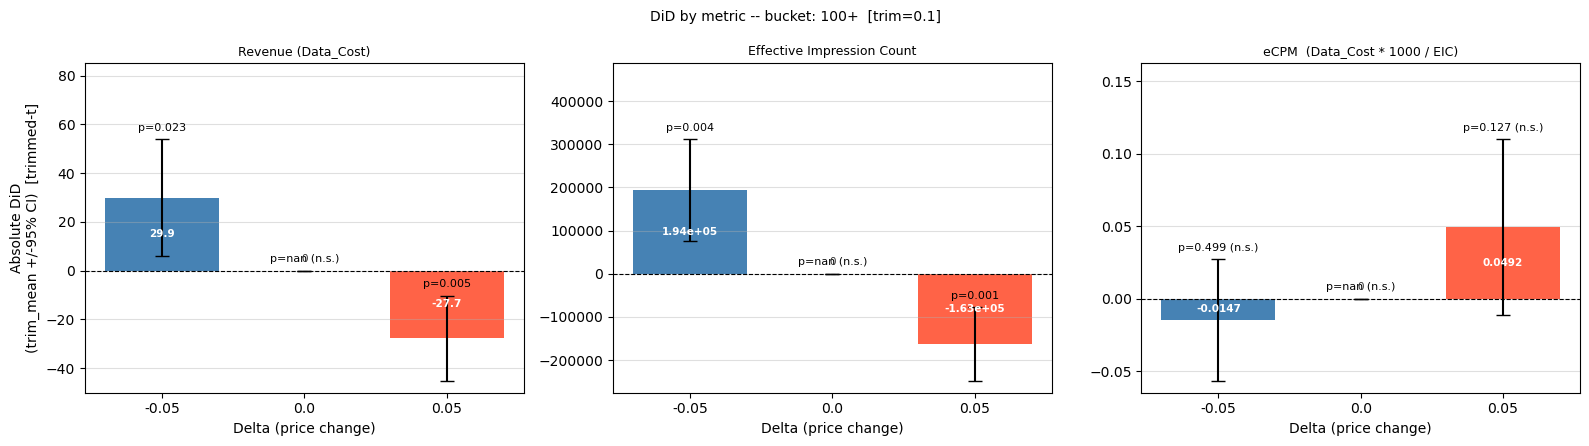

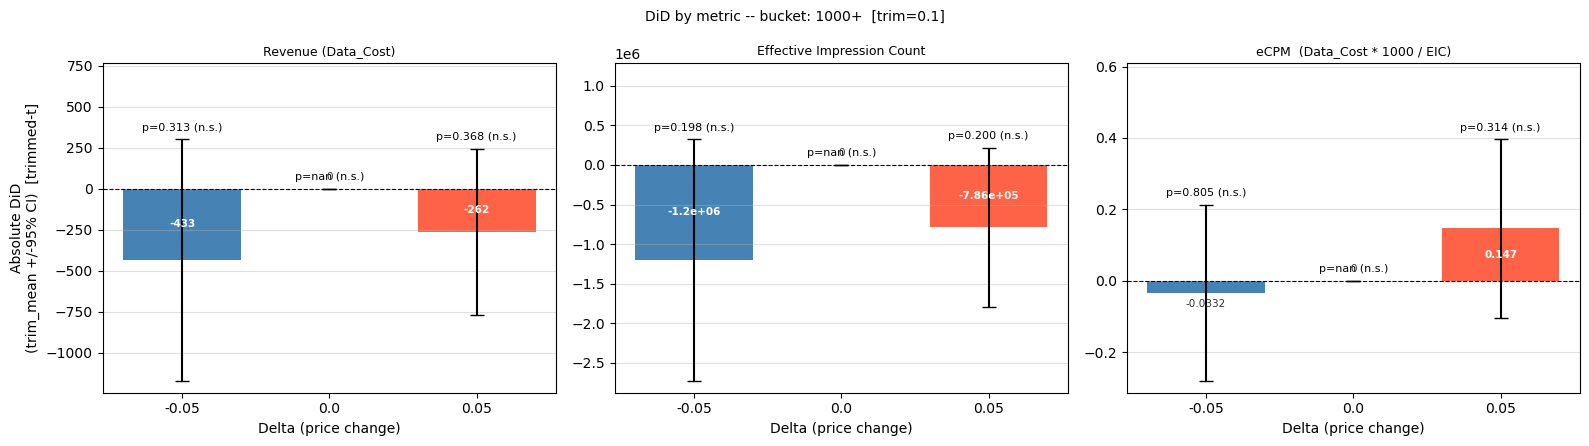

In [79]:
# ── Per-bucket stats tables ───────────────────────────────────────────────────
# `did_b` is the revenue DiD with bucket labels (defined in the earlier section).
# `did_vol` contains Revenue/EIC/eCPM DiDs with bucket labels -- absolute DiD
# only (see markdown above for why no per-segment relative version is computed).
_all_metrics_b = [
    (did_vol, 'did_rev',  'Revenue (Data_Cost)'),
    (did_vol, 'did_eic',  'Effective Impression Count'),
    (did_vol, 'did_ecpm', 'eCPM  (Data_Cost * 1000 / EIC)'),
]

for bucket in BUCKET_ORDER:
    print(f"\n{'=' * 65}")
    print(f"  Bucket: {bucket}")
    print(f"{'=' * 65}")
    for df, abs_col, name in _all_metrics_b:
        sub = df[df['bucket'] == bucket]
        print(f"\n  -- {name}  (n={len(sub)}) --")
        print(desc_stats_trim(sub, abs_col).to_string(index=False))

# ── Per-bucket charts (one 1x3 figure per bucket) ────────────────────────────
for bucket in BUCKET_ORDER:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for col_idx, (df, abs_col, name) in enumerate(_all_metrics_b):
        sub = df[df['bucket'] == bucket]
        ax = axes[col_idx]
        plot_did_bars(ax, sub, abs_col, metric='mean', trim=_TRIM)
        ax.set_xlabel('Delta (price change)')
        ax.set_title(name, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel('Absolute DiD\n(trim_mean +/-95% CI)  [trimmed-t]')
    fig.suptitle(f'DiD by metric -- bucket: {bucket}  [trim={_TRIM}]', fontsize=10)
    plt.tight_layout()
    plt.show()
